In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import re

In [2]:
# Define all subdirectories in nixround (long-run notebook)
nixround_base = Path('nixround')

def resolve_dataset_path(base, *candidates):
    for rel in candidates:
        candidate = base / rel
        if candidate.exists():
            return candidate
    # Keep notebook runnable even if folders are not present yet.
    return base / candidates[0]

subdirs = {
    'base_linux': resolve_dataset_path(nixround_base, 'linux_long_base_nix'),
    'base_unikernel': resolve_dataset_path(nixround_base, 'unikernel_long_base_nix'),
    'optimized_linux_iso_eist_c-state_off': resolve_dataset_path(nixround_base, 'linux_long_ISO_nix'),
    'optimized_linux_wo_iso_eist_c-state_off': resolve_dataset_path(nixround_base, 'linux_long_OPT_nix'),
    'optimized_unikernel': resolve_dataset_path(nixround_base, 'unikernel_long_opt_nix'),
    'naive_linux': resolve_dataset_path(nixround_base, 'linux_naive_long'),
}

config_labels = {
    'naive_linux': 'Linux Naive',
    'base_linux': 'Linux Base',
    'optimized_linux_iso_eist_c-state_off': 'Linux Iso',
    'optimized_linux_wo_iso_eist_c-state_off': 'Linux Opt',
    'optimized_linux_wo_iso_eist_c-state_on': 'Linux Opt (C-state On)',
    'base_unikernel': 'Unikernel Base',
    'optimized_unikernel': 'Unikernel Opt',
}

print('Available subdirectories:')
for name, path in subdirs.items():
    pretty = config_labels.get(name, name)
    exists = 'exists' if path.exists() else 'missing'
    print(f'  {pretty}: {path} ({exists})')

Available subdirectories:
  Linux Base: nixround/linux_long_base_nix (exists)
  Unikernel Base: nixround/unikernel_long_base_nix (exists)
  Linux Iso: nixround/linux_long_ISO_nix (exists)
  Linux Opt: nixround/linux_long_OPT_nix (exists)
  Unikernel Opt: nixround/unikernel_long_opt_nix (exists)
  Linux Naive: nixround/linux_naive_long (exists)


In [3]:
# Load powermeter measurements (binary_output_*.log files)
powermeter_data = {}

for name, path in subdirs.items():
    powermeter_data[name] = {}
    
    # Get all .log files in the directory
    log_files = sorted(path.glob('binary_output_*.log'))
    
    for log_file in log_files:
        # Extract benchmark name and iteration number from filename
        # e.g., binary_output_crc32_0.log -> benchmark=crc32, iteration=0
        match = re.match(r'binary_output_(.+)_(\d+)\.log', log_file.name)
        if match:
            benchmark = match.group(1)
            iteration = int(match.group(2))
            
            # Initialize benchmark dict if needed
            if benchmark not in powermeter_data[name]:
                powermeter_data[name][benchmark] = {}
            
            # Load the log file
            try:
                df = pd.read_csv(log_file)
                powermeter_data[name][benchmark][iteration] = df
            except Exception as e:
                print(f"Error loading {log_file}: {e}")

# Print summary
print("Powermeter data summary:")
for config_name, benchmarks in powermeter_data.items():
    total_files = sum(len(iterations) for iterations in benchmarks.values())
    print(f"  {config_name}: {len(benchmarks)} benchmarks, {total_files} total files")

Error loading nixround/linux_naive_long/binary_output_cubic_3.log: No columns to parse from file
Powermeter data summary:
  base_linux: 9 benchmarks, 450 total files
  base_unikernel: 9 benchmarks, 450 total files
  optimized_linux_iso_eist_c-state_off: 9 benchmarks, 450 total files
  optimized_linux_wo_iso_eist_c-state_off: 9 benchmarks, 450 total files
  optimized_unikernel: 9 benchmarks, 450 total files
  naive_linux: 9 benchmarks, 449 total files


In [4]:
# Display sample powermeter data
config = 'base_linux'
benchmark = 'crc32'
iteration = 0

if config in powermeter_data and benchmark in powermeter_data[config]:
    if iteration in powermeter_data[config][benchmark]:
        print(f"Sample powermeter data from {config} / {benchmark} / iteration {iteration}:")
        print(powermeter_data[config][benchmark][iteration].head(10))
        print(f"\nShape: {powermeter_data[config][benchmark][iteration].shape}")
    else:
        print(f"Iteration {iteration} not found")
else:
    print(f"Config or benchmark not found")

Sample powermeter data from base_linux / crc32 / iteration 0:
     unix_timestamp  active_power (mW)
0  1774520741470623              49300
1  1774520741513765              46230
2  1774520741556861              44950
3  1774520741601973              44650
4  1774520741645040              44710
5  1774520741688044              44720
6  1774520741731152              44800
7  1774520741774177              44710
8  1774520741817196              44720
9  1774520741860347              44690

Shape: (391, 2)


In [5]:
# Display structure of powermeter data
print("Benchmarks found per configuration:")
for config_name, benchmarks in powermeter_data.items():
    benchmark_list = sorted(benchmarks.keys())
    iterations = [len(benchmarks[b]) for b in benchmark_list]
    print(f"\n{config_name}:")
    print(f"  Benchmarks: {benchmark_list}")
    print(f"  Iterations per benchmark: {iterations[0] if iterations else 0} (first benchmark)")

Benchmarks found per configuration:

base_linux:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

base_unikernel:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

optimized_linux_iso_eist_c-state_off:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

optimized_linux_wo_iso_eist_c-state_off:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

optimized_unikernel:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50

In [6]:
# Load PC measurements (unikernel_output.csv from each directory)
pc_data = {}

for name, path in subdirs.items():
    csv_file = path / 'unikernel_output.csv'
    if csv_file.exists():
        df = pd.read_csv(csv_file)
        pc_data[name] = df
        print(f"Loaded {name}: {len(df)} rows, {len(df.columns)} columns")
    else:
        print(f"Warning: {csv_file} not found")

print(f"\nTotal configurations loaded: {len(pc_data)}")

Loaded base_linux: 450 rows, 21 columns
Loaded base_unikernel: 451 rows, 21 columns
Loaded optimized_linux_iso_eist_c-state_off: 450 rows, 21 columns
Loaded optimized_linux_wo_iso_eist_c-state_off: 450 rows, 21 columns
Loaded optimized_unikernel: 450 rows, 21 columns
Loaded naive_linux: 451 rows, 21 columns

Total configurations loaded: 6


In [7]:
# Display sample PC data for one configuration
print("Sample PC data from base_linux:")
print(pc_data['base_linux'].head())

Sample PC data from base_linux:
  benchmark   cpu_cycles   cycles_start     cycles_end       time_ns  \
0     crc32  52266145859  8220299896062  8272566041921  1.689867e+10   
1     crc32  52267271222  8272567508634  8324834779856  1.689883e+10   
2     crc32  52261445460  8324835758962  8377097204422  1.689694e+10   
3     crc32  52266102194  8377098185412  8429364287606  1.689845e+10   
4     crc32  52260991812  8429365263952  8481626255764  1.689680e+10   

        time_ms  cooldown_ms  temp_before  temp_after  pkg_temp_before  ...  \
0  16898.666068        4.734         38.0        37.0             45.0  ...   
1  16898.825912        0.020         37.0        38.0             45.0  ...   
2  16896.944675        0.018         38.0        38.0             45.0  ...   
3  16898.449354        0.018         38.0        38.0             45.0  ...   
4  16896.796056        0.018         38.0        40.0             45.0  ...   

   pkg_joules      pkg_mJ  pp0_joules      pp0_mJ  pp1_joule

In [8]:
# Calculate energy consumption from powermeter data and compare with pkg energy
# Energy = Average Power (W) × Time (s)

energy_results = []

for config_name in subdirs.keys():
    # Get PC data for this config
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    
    # Get unique benchmarks from PC data
    benchmarks_in_config = pc_df['benchmark'].unique()
    
    for benchmark in benchmarks_in_config:
        # Get PC measurements for this benchmark
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        # Skip if no data found for this benchmark
        if len(pc_bench) == 0:
            continue
        
        # Calculate mean and std for pkg energy from PC data (in Joules)
        pkg_energies = pc_bench['pkg_joules'].values
        mean_pkg_joules = pkg_energies.mean()
        std_pkg_joules = pkg_energies.std()
        mean_time_ms = pc_bench['cpu_cycles'].mean() / 3.1e6  # Convert cycles to ms at 3.1 GHz
        
        # Calculate energy from powermeter data if available
        if config_name in powermeter_data and benchmark in powermeter_data[config_name]:
            powermeter_energies = []
            
            for iteration, pm_df in powermeter_data[config_name][benchmark].items():
                # Skip empty or very small DataFrames (need at least 2 points for time span)
                if len(pm_df) < 2:
                    continue
                
                # Skip if iteration index is out of bounds
                if iteration >= len(pc_bench):
                    continue
                    
                # Get average power in Watts (convert mW to W)
                avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                
                # Get time span from CPU cycles
                cpu_cycles = pc_bench.iloc[iteration]['cpu_cycles']
                time_span_s = cpu_cycles / 3.1e9  # Convert cycles to seconds at 3.1 GHz
                
                # Calculate energy in Joules
                energy_j = avg_power_w * time_span_s
                powermeter_energies.append(energy_j)
            
            mean_powermeter_energy = np.mean(powermeter_energies) if powermeter_energies else None
            std_powermeter_energy = np.std(powermeter_energies) if powermeter_energies else None
        else:
            mean_powermeter_energy = None
            std_powermeter_energy = None
        
        energy_results.append({
            'config': config_name,
            'benchmark': benchmark,
            'pkg_energy_j': mean_pkg_joules,
            'pkg_energy_std': std_pkg_joules,
            'powermeter_energy_j': mean_powermeter_energy,
            'powermeter_energy_std': std_powermeter_energy,
            'time_ms': mean_time_ms
        })

# Convert to DataFrame for easier plotting
energy_df = pd.DataFrame(energy_results)
print(f"Energy analysis ready: {len(energy_df)} benchmark-config combinations")
print(energy_df.head(10))

Energy analysis ready: 54 benchmark-config combinations
           config      benchmark  pkg_energy_j  pkg_energy_std  \
0      base_linux          crc32    299.580637        1.352213   
1      base_linux          cubic    265.788860        0.313614   
2      base_linux       dijkstra    367.873086        0.664925   
3      base_linux           fdct    294.055305        0.246282   
4      base_linux            fir    250.209513        0.178885   
5      base_linux  matmult-float    337.002402        3.498904   
6      base_linux    matmult-int    311.103169        1.698097   
7      base_linux  nettle-sha256    382.543575        0.221495   
8      base_linux       rijndael    340.378304        0.240913   
9  base_unikernel          crc32    266.650016        0.312876   

   powermeter_energy_j  powermeter_energy_std       time_ms  
0           759.259123               1.510599  16860.624766  
1           650.810495               0.393442  13751.382722  
2           860.346075         

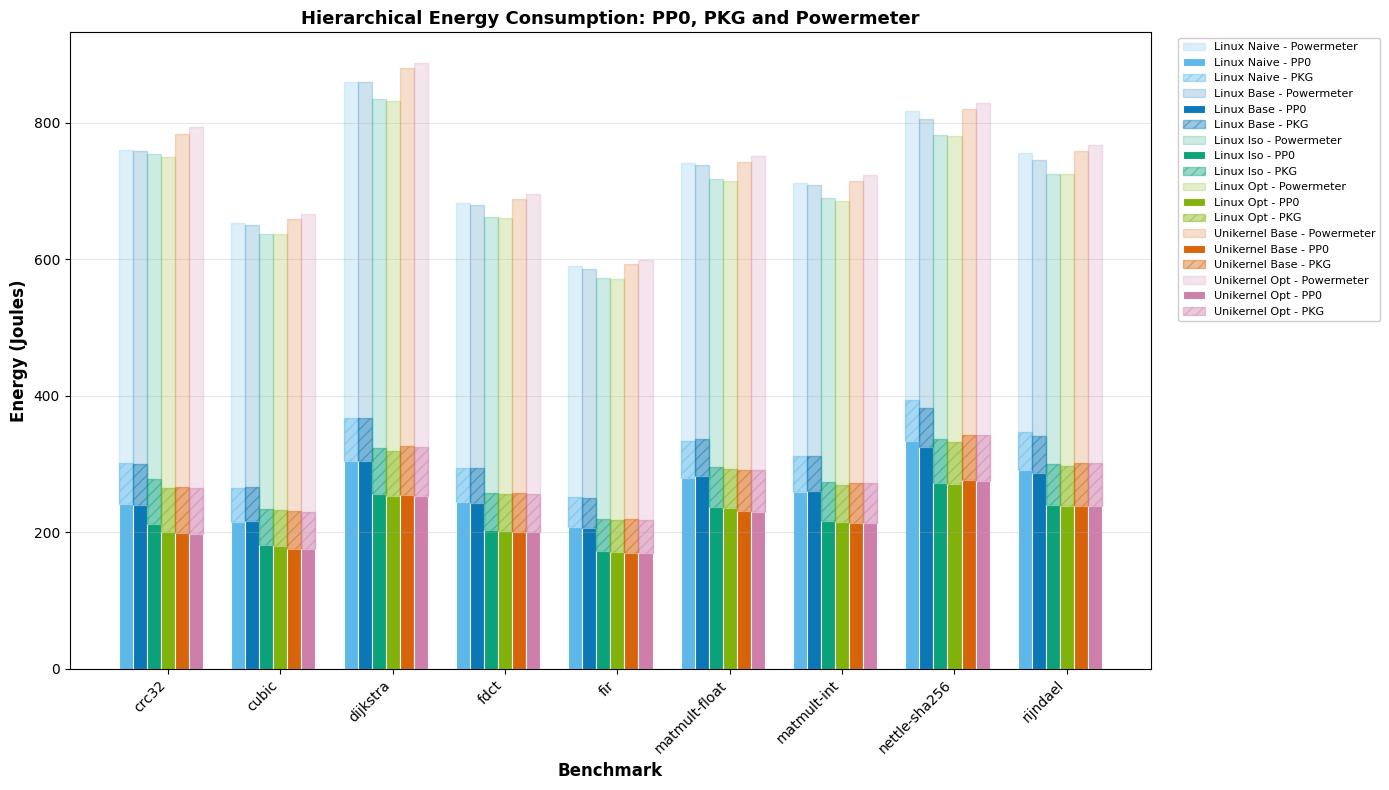

In [9]:
# Create plot showing hierarchical energy consumption: PP0 + Uncore = PKG
# Keep powermeter (PM) measurements visible as a light background bar
fig, ax = plt.subplots(figsize=(14, 8))

# Filter out specific configurations for plotting
plot_df = energy_df[
    (energy_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on')
].copy()

# Get unique benchmarks and configs (filter out NaN values)
benchmarks = sorted([b for b in plot_df['benchmark'].unique() if pd.notna(b)])

# Define custom order for configs (mapped to this notebook's config keys)
config_order = [
    'naive_linux',
    'base_linux',
    'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off',
    'base_unikernel',
    'optimized_unikernel'
 ]

# Filter to only configs present in data, maintaining the desired order
configs = [c for c in config_order if c in plot_df['config'].unique()]

# Use global config label mapping
config_names = config_labels

# Use the same config color mapping as CV plots
config_colors = {
    'naive_linux': '#56B4E9',
    'base_linux': '#0072B2',
    'optimized_linux_iso_eist_c-state_off': '#009E73',
    'optimized_linux_wo_iso_eist_c-state_off': '#7CAE00',
    'base_unikernel': '#D55E00',
    'optimized_unikernel': '#CC79A7'
}

# Set up x positions for grouped bars
x = np.arange(len(benchmarks)) * 1.2
width = 0.15

# Plot bars for each configuration
for i, config in enumerate(configs):
    config_data = plot_df[plot_df['config'] == config]
    short_name = config_names.get(config, config)
    bar_color = config_colors.get(config, '#7f7f7f')

    # Prepare data aligned with benchmark order
    pm_energies = []
    pkg_energies = []
    pp0_energies = []
    uncore_energies = []

    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0:
            pm_val = bench_data['powermeter_energy_j'].values[0]
            pkg_val = bench_data['pkg_energy_j'].values[0]

            # Get PP0 data from pc_data
            if config in pc_data:
                pc_bench = pc_data[config][pc_data[config]['benchmark'] == bench]
                pp0_val = pc_bench['pp0_joules'].mean() if len(pc_bench) > 0 else 0
            else:
                pp0_val = 0

            # Handle None values and derive Uncore = PKG - PP0
            pm_clean = pm_val if pd.notna(pm_val) else 0
            pkg_clean = pkg_val if pd.notna(pkg_val) else 0
            pp0_clean = pp0_val if pd.notna(pp0_val) else 0
            uncore_clean = max(pkg_clean - pp0_clean, 0)

            pm_energies.append(pm_clean)
            pkg_energies.append(pkg_clean)
            pp0_energies.append(pp0_clean)
            uncore_energies.append(uncore_clean)
        else:
            pm_energies.append(0)
            pkg_energies.append(0)
            pp0_energies.append(0)
            uncore_energies.append(0)

    # Plot bars at same x offset:
    # - PM total system (light background)
    # - PP0 core energy (base)
    # - Uncore = PKG - PP0 (hatched top layer)
    offset = (i - len(configs) / 2) * width

    ax.bar(
        x + offset,
        pm_energies,
        width,
        label=f'{short_name} - Powermeter',
        color=bar_color,
        alpha=0.2,
        edgecolor=bar_color,
        linewidth=1.0
    )

    ax.bar(
        x + offset,
        pp0_energies,
        width,
        label=f'{short_name} - PP0',
        color=bar_color,
        alpha=0.95,
        edgecolor='white',
        linewidth=0.8
    )

    ax.bar(
        x + offset,
        uncore_energies,
        width,
        bottom=pp0_energies,
        label=f'{short_name} - PKG',
        color=bar_color,
        alpha=0.4,
        edgecolor=bar_color,
        linewidth=1.0,
        hatch='///'
    )

ax.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
ax.set_title('Hierarchical Energy Consumption: PP0, PKG and Powermeter',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(benchmarks, rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=1, framealpha=0.95)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Calculate coefficient of variation (CV) for energy measurements
# CV = (std / mean) * 100%

cv_results = []

for config_name in subdirs.keys():
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    benchmarks_in_config = pc_df['benchmark'].unique()
    
    for benchmark in benchmarks_in_config:
        # Get all PKG energy values for this benchmark
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        pkg_energies = pc_bench['pkg_joules'].values
        
        # Calculate PKG CV
        if len(pkg_energies) > 1:
            pkg_cv = (pkg_energies.std() / pkg_energies.mean()) * 100
        else:
            pkg_cv = None
        
        # Calculate powermeter CV if available
        if config_name in powermeter_data and benchmark in powermeter_data[config_name]:
            powermeter_energies = []
            
            for iteration, pm_df in powermeter_data[config_name][benchmark].items():
                if len(pm_df) < 2:
                    continue
                
                time_span_s = pc_bench.iloc[iteration]['cpu_cycles'] / 3.1e9  # Convert cycles to seconds at 3.1 GHz

                avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                energy_j = avg_power_w * time_span_s
                powermeter_energies.append(energy_j)
            
            if len(powermeter_energies) > 1:
                pm_cv = (np.std(powermeter_energies) / np.mean(powermeter_energies)) * 100
            else:
                pm_cv = None
        else:
            pm_cv = None
        
        cv_results.append({
            'config': config_name,
            'benchmark': benchmark,
            'pkg_cv': pkg_cv,
            'powermeter_cv': pm_cv
        })

# Convert to DataFrame
cv_df = pd.DataFrame(cv_results)
print(f"CV analysis ready: {len(cv_df)} benchmark-config combinations")

# Print only Linux Naive + crc32 CV row
linux_naive_crc32 = cv_df[
    (cv_df['config'] == 'base_linux') &
    (cv_df['benchmark'] == 'crc32')
]
print(linux_naive_crc32[['config', 'benchmark', 'pkg_cv', 'powermeter_cv' ]])

CV analysis ready: 56 benchmark-config combinations
       config benchmark    pkg_cv  powermeter_cv
0  base_linux     crc32  0.451369       0.198957


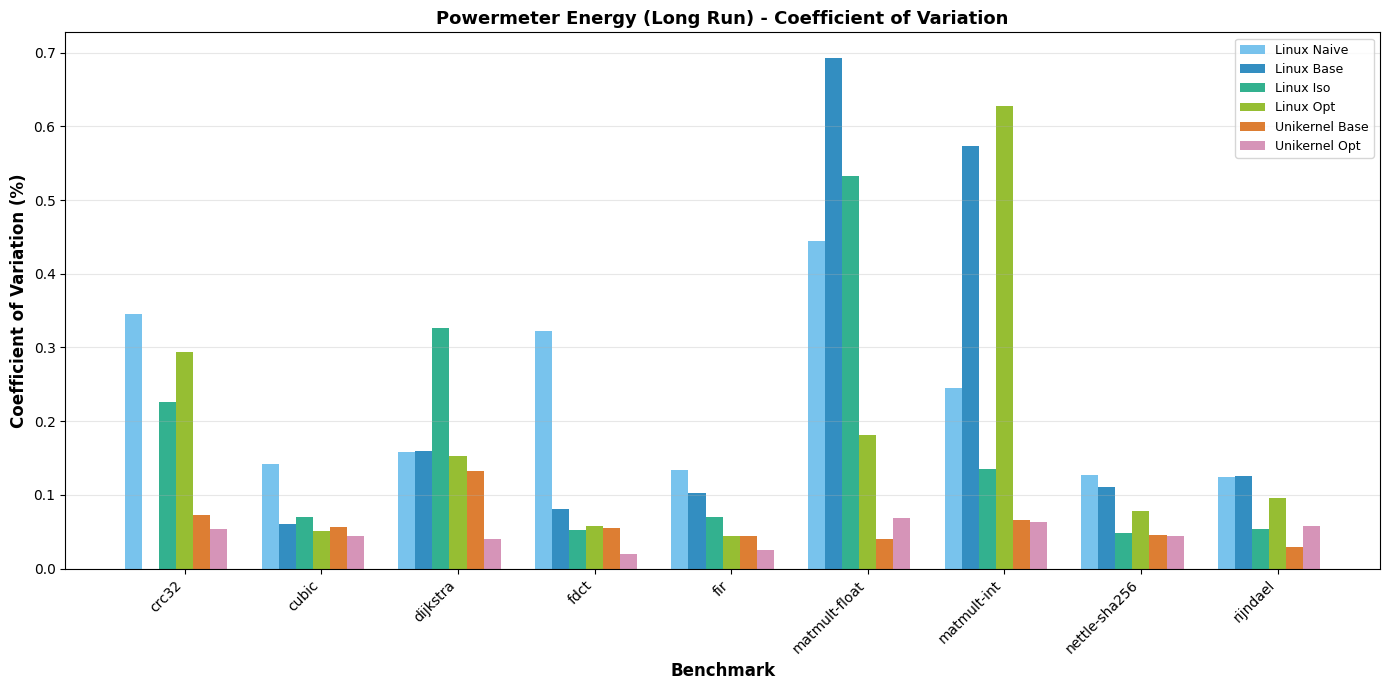

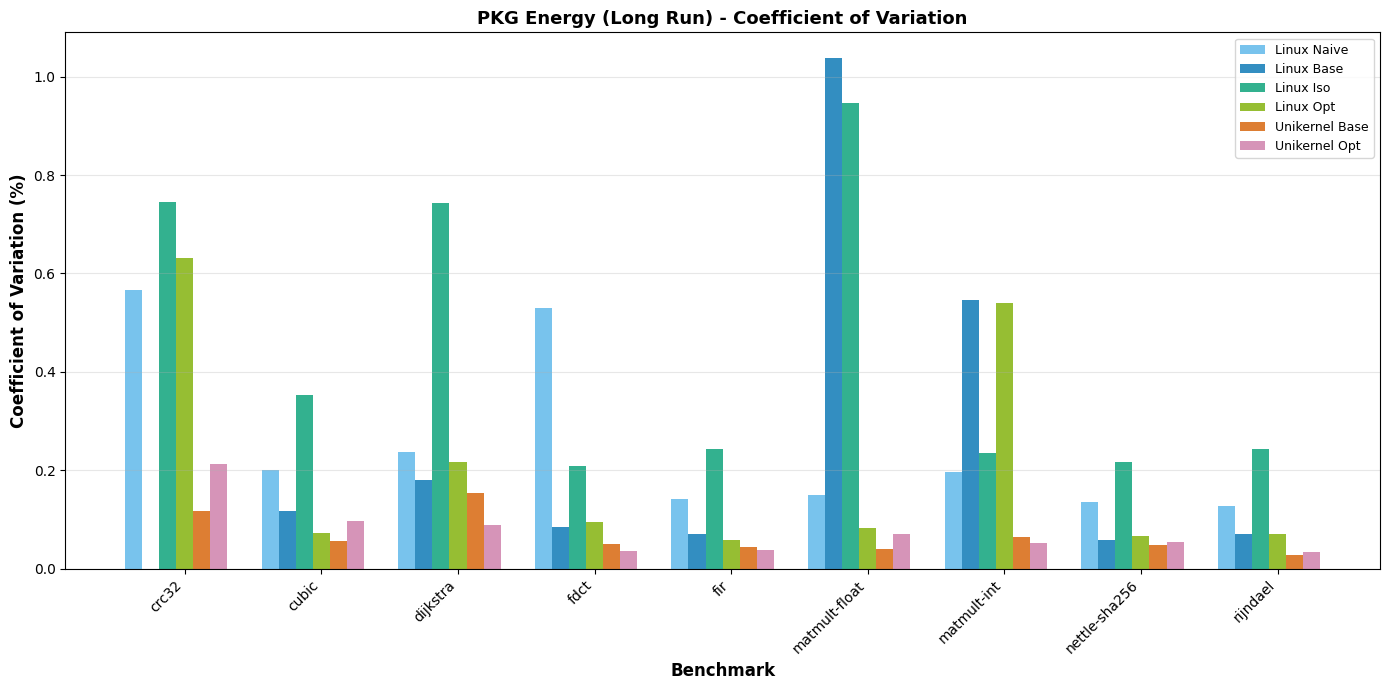

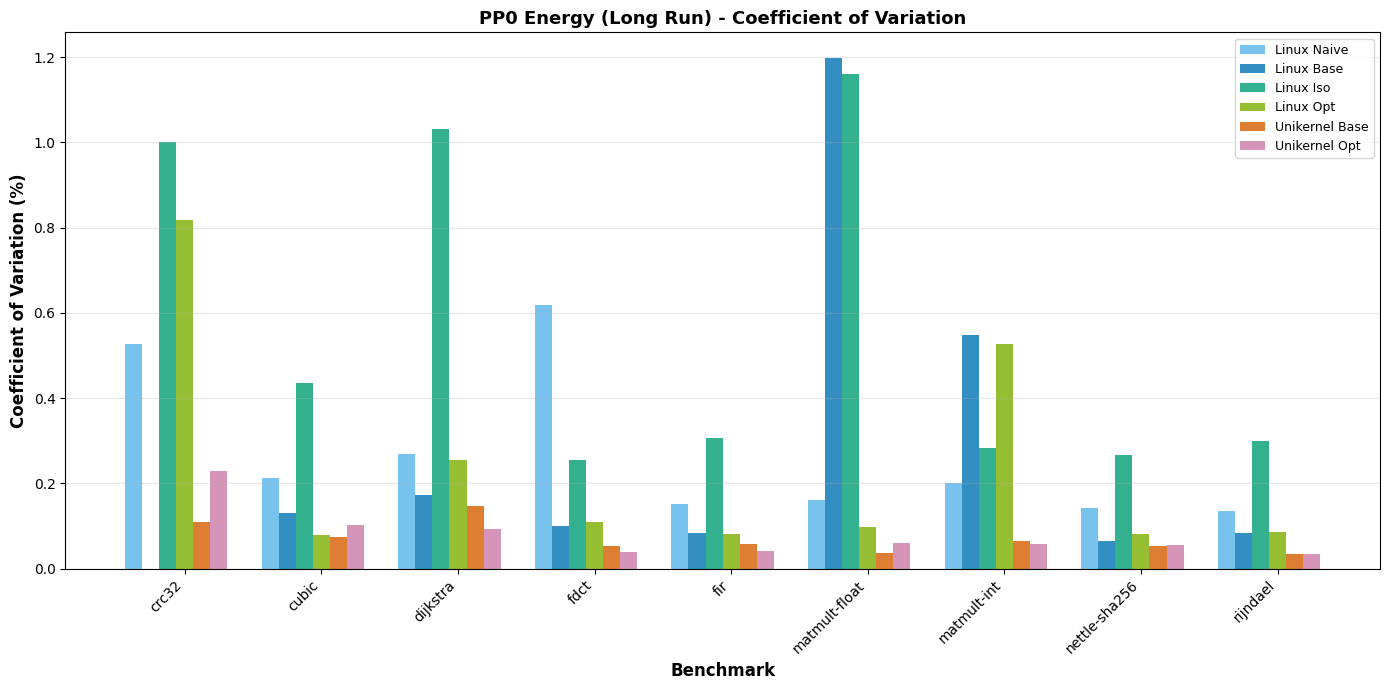

In [11]:
# Create three separate plots for coefficient of variation
# Filter out specific configurations and base_linux crc32 only for plotting
cv_plot_df = cv_df[
    (cv_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on') &
    ~((cv_df['config'] == 'base_linux') & (cv_df['benchmark'] == 'crc32'))
].copy()

# Get unique benchmarks and configs
benchmarks = sorted([b for b in cv_plot_df['benchmark'].unique() if pd.notna(b)])

# Define custom order for configs
config_order = [
    'naive_linux',
    'base_linux',
    'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in cv_plot_df['config'].unique()]

# Set up x positions
x = np.arange(len(benchmarks)) * 1.2
width = 0.15
config_colors = {
    'naive_linux': '#56B4E9',
    'base_linux': '#0072B2',
    'optimized_linux_iso_eist_c-state_off': '#009E73',
    'optimized_linux_wo_iso_eist_c-state_off': '#7CAE00',
    'base_unikernel': '#D55E00',
    'optimized_unikernel': '#CC79A7'
}

# Plot 1: Powermeter CV
fig1, ax1 = plt.subplots(figsize=(14, 7))

for i, config in enumerate(configs):
    config_data = cv_plot_df[cv_plot_df['config'] == config]
    label = config_labels.get(config, config)
    
    pm_cvs = []
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0 and pd.notna(bench_data['powermeter_cv'].values[0]):
            pm_cvs.append(bench_data['powermeter_cv'].values[0])
        else:
            pm_cvs.append(0)
    
    offset = (i - len(configs)/2) * width
    ax1.bar(x + offset, pm_cvs, width, label=label, color=config_colors.get(config, '#7f7f7f'), alpha=0.8)

ax1.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax1.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax1.set_title('Powermeter Energy (Long Run) - Coefficient of Variation', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(benchmarks, rotation=45, ha='right')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: PKG CV
fig2, ax2 = plt.subplots(figsize=(14, 7))

for i, config in enumerate(configs):
    config_data = cv_plot_df[cv_plot_df['config'] == config]
    label = config_labels.get(config, config)
    
    pkg_cvs = []
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0 and pd.notna(bench_data['pkg_cv'].values[0]):
            pkg_cvs.append(bench_data['pkg_cv'].values[0])
        else:
            pkg_cvs.append(0)
    
    offset = (i - len(configs)/2) * width
    ax2.bar(x + offset, pkg_cvs, width, label=label, color=config_colors.get(config, '#7f7f7f'), alpha=0.8)

ax2.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax2.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax2.set_title('PKG Energy (Long Run) - Coefficient of Variation', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(benchmarks, rotation=45, ha='right')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: PP0 CV
# Calculate PP0 CV results
pp0_cv_results = []

for config_name in subdirs.keys():
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    benchmarks_in_config = pc_df['benchmark'].unique()
    
    for benchmark in benchmarks_in_config:
        # Get all PP0 energy values for this benchmark
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        pp0_energies = pc_bench['pp0_joules'].values
        
        # Calculate PP0 CV
        if len(pp0_energies) > 1:
            pp0_cv = (pp0_energies.std() / pp0_energies.mean()) * 100
        else:
            pp0_cv = None
        
        pp0_cv_results.append({
            'config': config_name,
            'benchmark': benchmark,
            'pp0_cv': pp0_cv
        })

# Convert to DataFrame
pp0_cv_df = pd.DataFrame(pp0_cv_results)

# Filter out specific configurations and base_linux crc32 only for plotting
pp0_cv_plot_df = pp0_cv_df[
    (pp0_cv_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on') &
    ~((pp0_cv_df['config'] == 'base_linux') & (pp0_cv_df['benchmark'] == 'crc32'))
].copy()

fig3, ax3 = plt.subplots(figsize=(14, 7))

for i, config in enumerate(configs):
    config_data = pp0_cv_plot_df[pp0_cv_plot_df['config'] == config]
    label = config_labels.get(config, config)
    
    pp0_cvs = []
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0 and pd.notna(bench_data['pp0_cv'].values[0]):
            pp0_cvs.append(bench_data['pp0_cv'].values[0])
        else:
            pp0_cvs.append(0)
    
    offset = (i - len(configs)/2) * width
    ax3.bar(x + offset, pp0_cvs, width, label=label, color=config_colors.get(config, '#7f7f7f'), alpha=0.8)

ax3.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax3.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax3.set_title('PP0 Energy (Long Run) - Coefficient of Variation', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(benchmarks, rotation=45, ha='right')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Saved: boxplots/pkg/boxplot_pkg_crc32.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/143782916.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


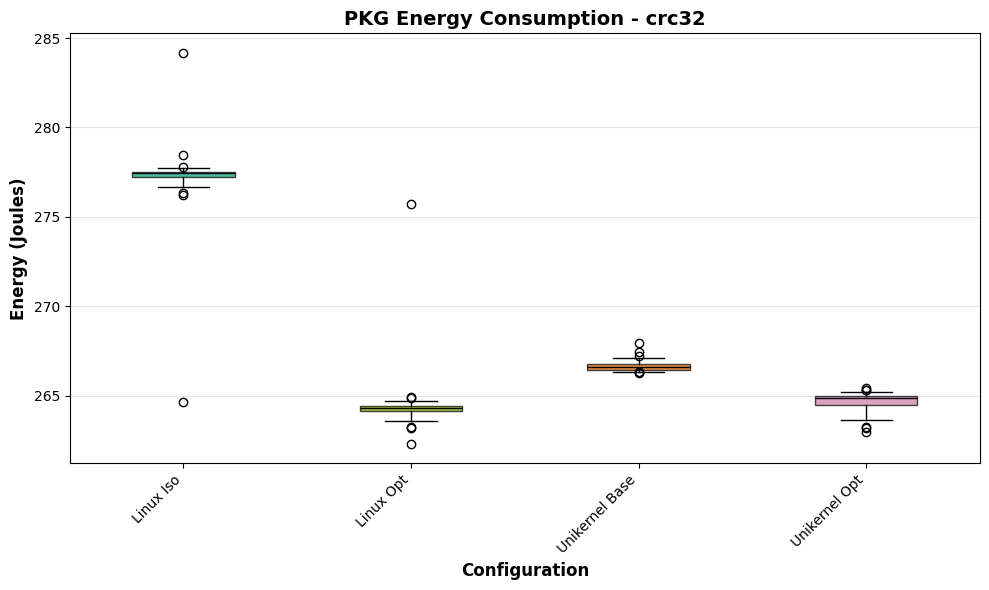

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/143782916.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/pkg/boxplot_pkg_cubic.png


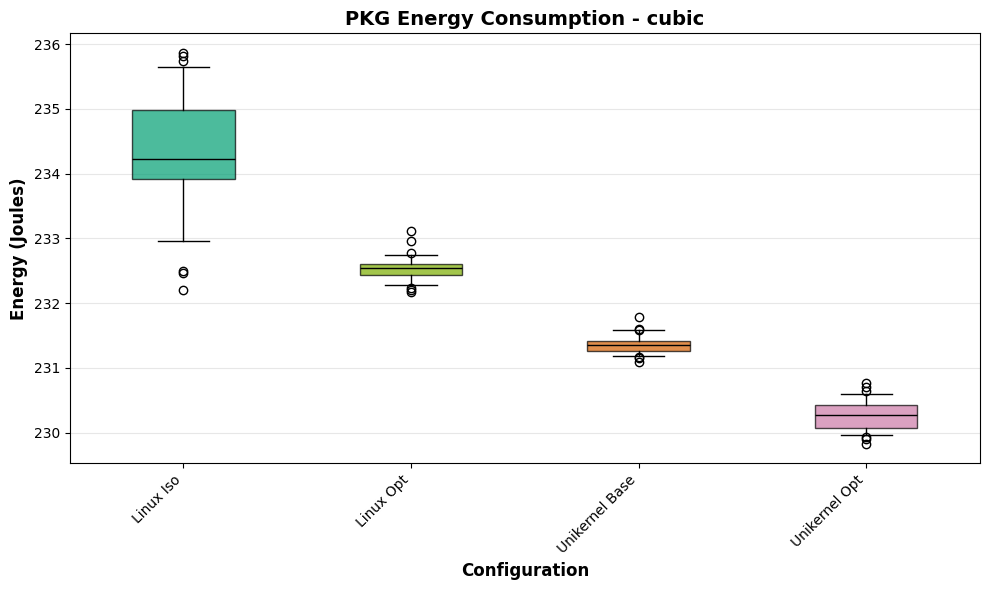

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/143782916.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/pkg/boxplot_pkg_dijkstra.png


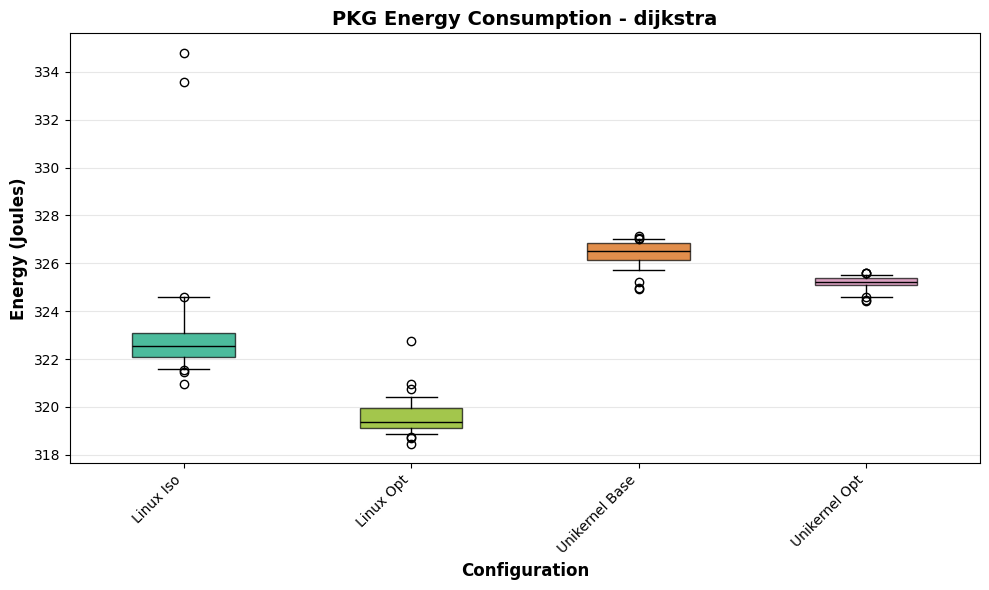

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/143782916.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/pkg/boxplot_pkg_fdct.png


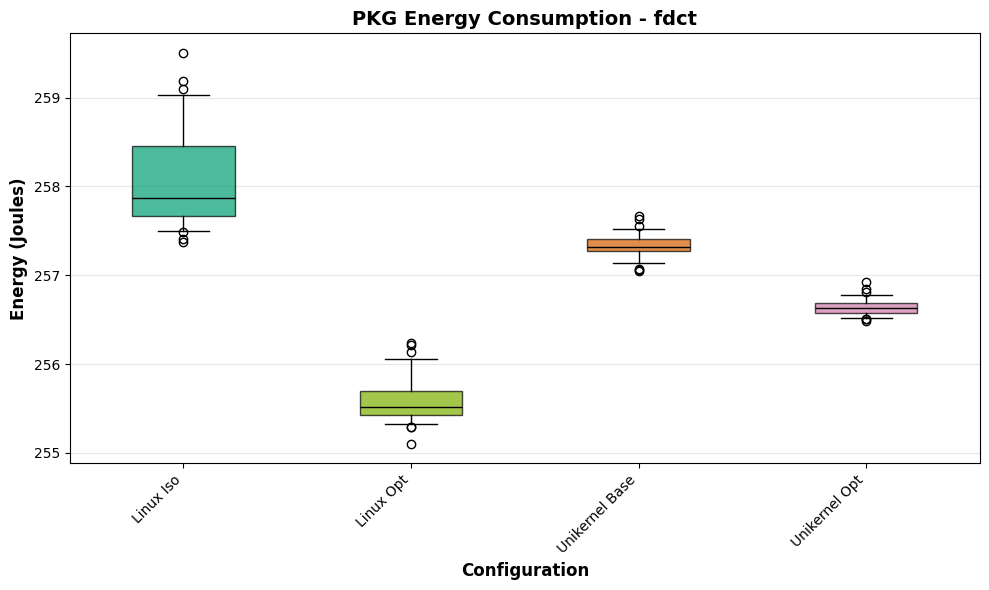

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/143782916.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/pkg/boxplot_pkg_fir.png


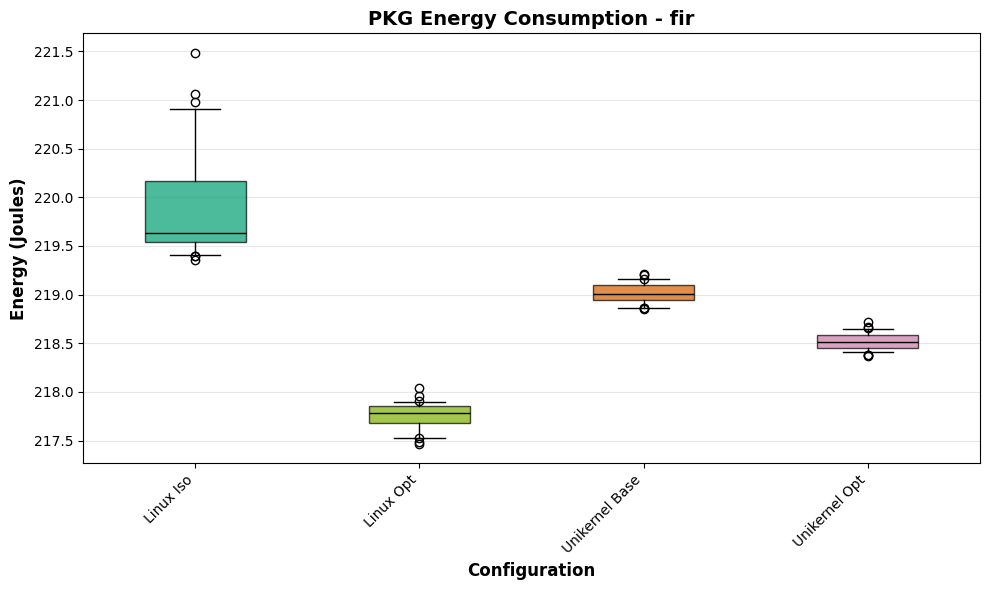

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/143782916.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/pkg/boxplot_pkg_matmult-float.png


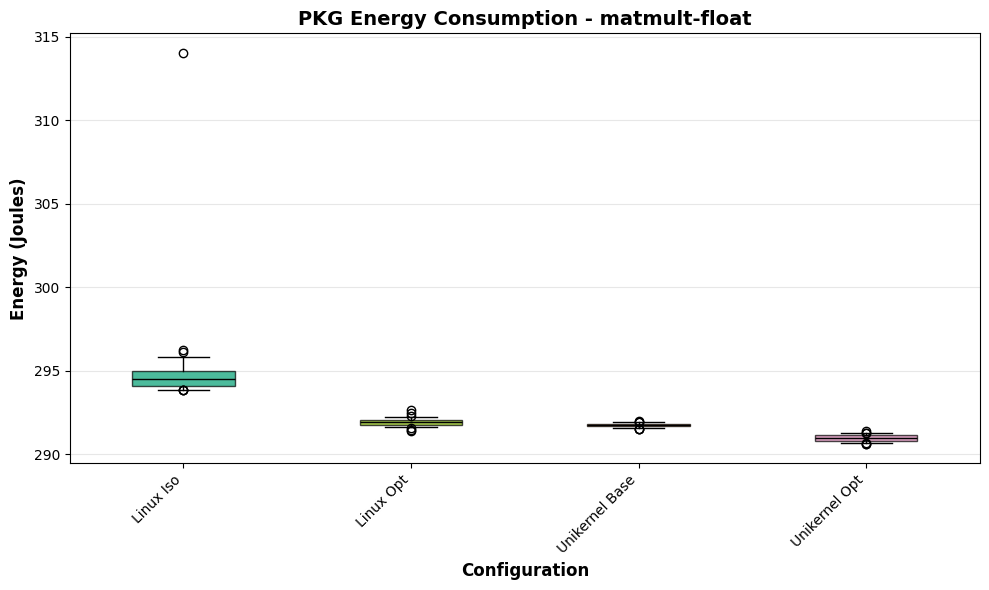

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/143782916.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/pkg/boxplot_pkg_matmult-int.png


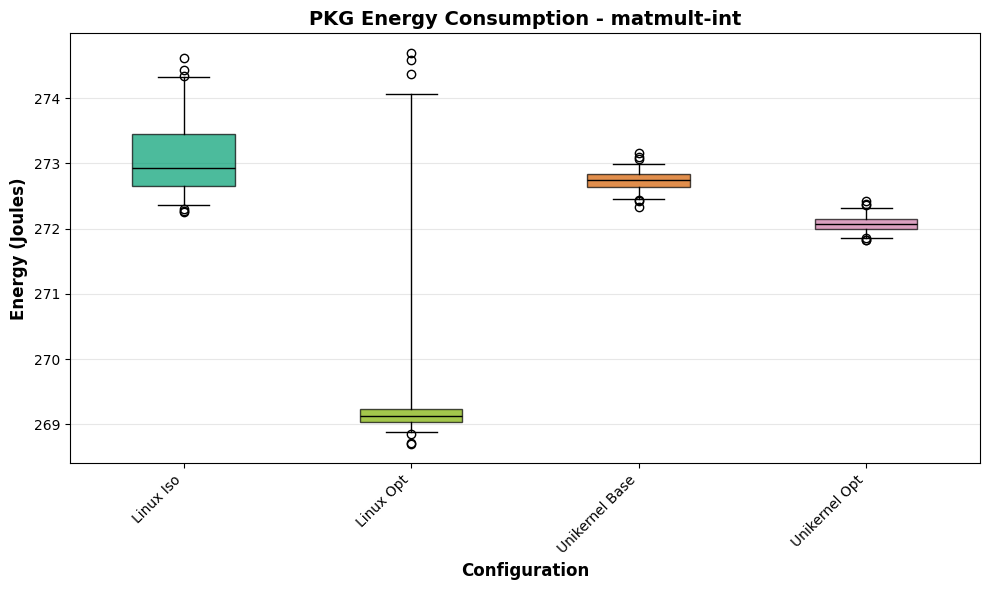

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/143782916.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/pkg/boxplot_pkg_nettle-sha256.png


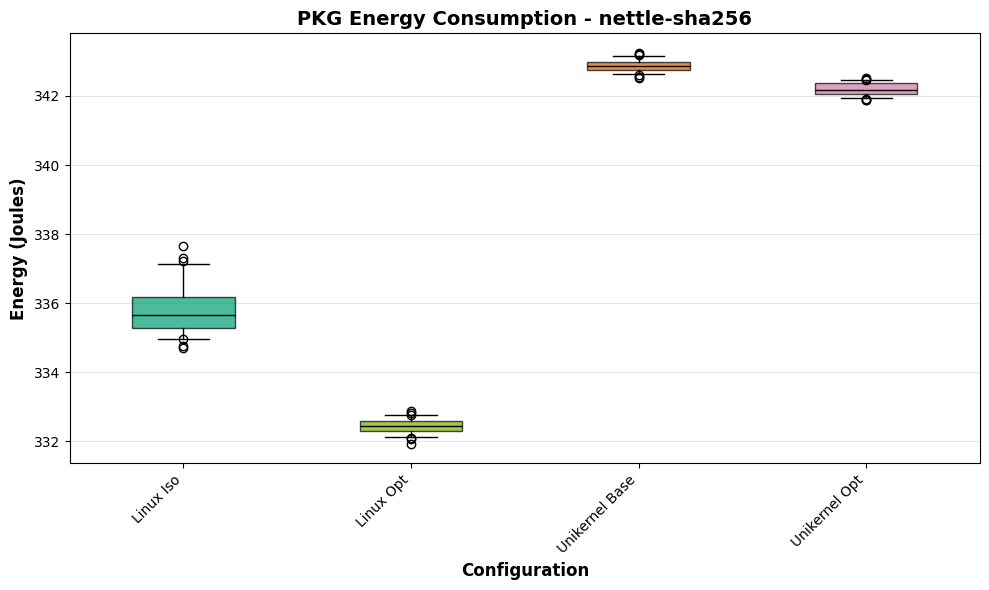

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/143782916.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/pkg/boxplot_pkg_rijndael.png


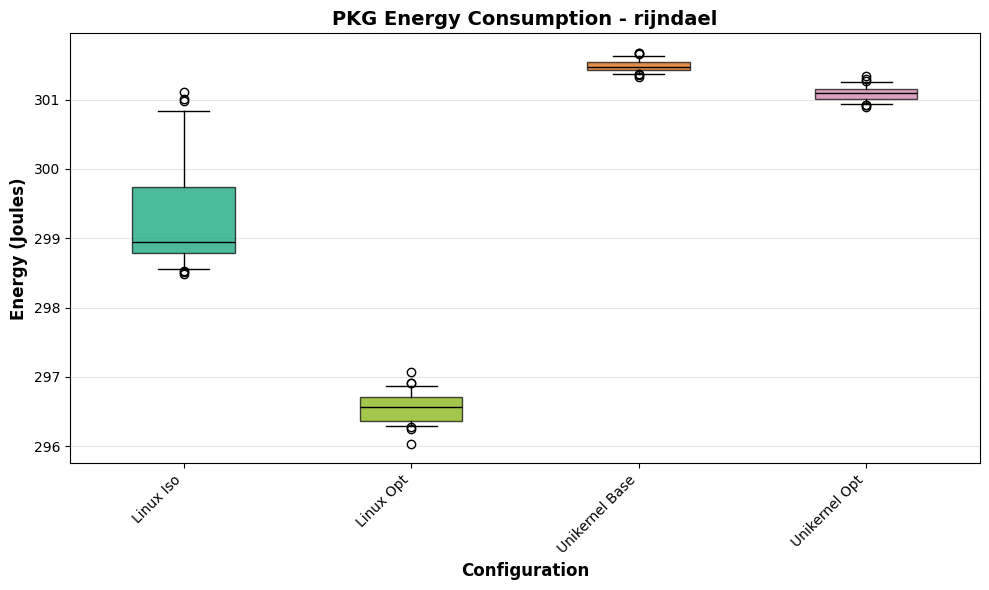

In [12]:
# Boxplot for PKG energy consumption per benchmark
# One plot per benchmark, showing all configurations

plot_df = energy_df[
    (energy_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on') &
    ~((energy_df['config'] == 'base_linux') & (energy_df['benchmark'] == 'crc32'))
] .copy()

# Get unique benchmarks
benchmarks = sorted([b for b in plot_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    # 'naive_linux',
    # 'base_linux',
    'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys() and c != 'optimized_linux_wo_iso_eist_c-state_on']

# Configuration colors
config_colors = {
    'naive_linux': '#56B4E9',
    'base_linux': '#0072B2',
    'optimized_linux_iso_eist_c-state_off': '#009E73',
    'optimized_linux_wo_iso_eist_c-state_off': '#7CAE00',
    'base_unikernel': '#D55E00',
    'optimized_unikernel': '#CC79A7'
}

# Create output directory
output_dir = Path('boxplots/pkg')
output_dir.mkdir(parents=True, exist_ok=True)

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    config_list = []
    
    for config_name in configs:
        if config_name not in pc_data:
            continue
        
        pc_df = pc_data[config_name]
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 0:
            data_to_plot.append(pc_bench['pkg_joules'].values)
            labels.append(config_labels.get(config_name, config_name))
            config_list.append(config_name)
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))
        
        # Customize boxplot appearance with configuration colors
        for patch, config_name in zip(bp['boxes'], config_list):
            patch.set_facecolor(config_colors.get(config_name, '#7f7f7f'))
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
        ax.set_title(f'PKG Energy Consumption - {benchmark}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.xticks(rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        
        # Save figure
        filename = output_dir / f'boxplot_pkg_{benchmark}.png'
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"Saved: {filename}")
        
        plt.show()

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1022636604.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/powermeter/boxplot_powermeter_crc32.png


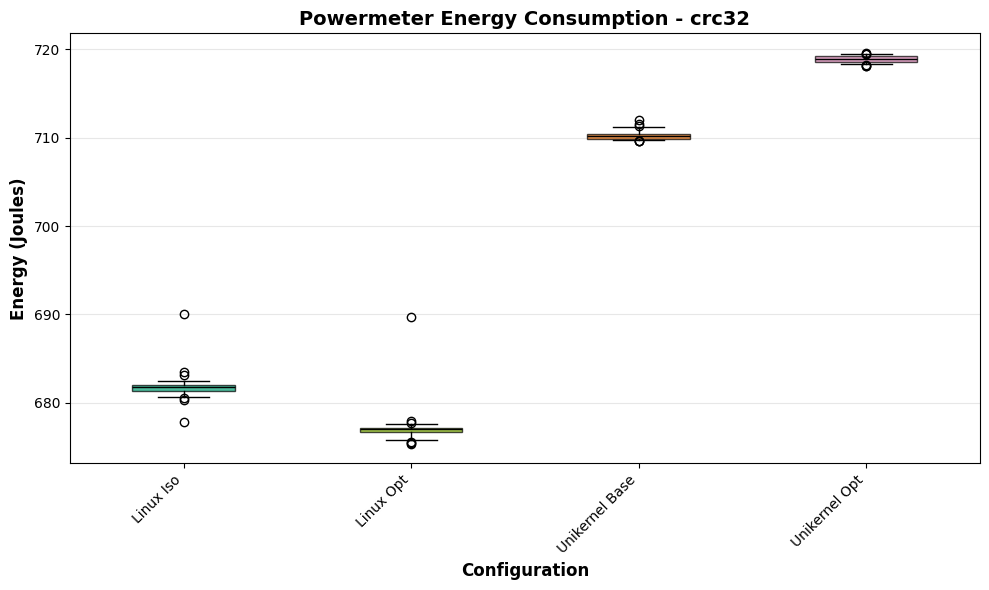

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1022636604.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/powermeter/boxplot_powermeter_cubic.png


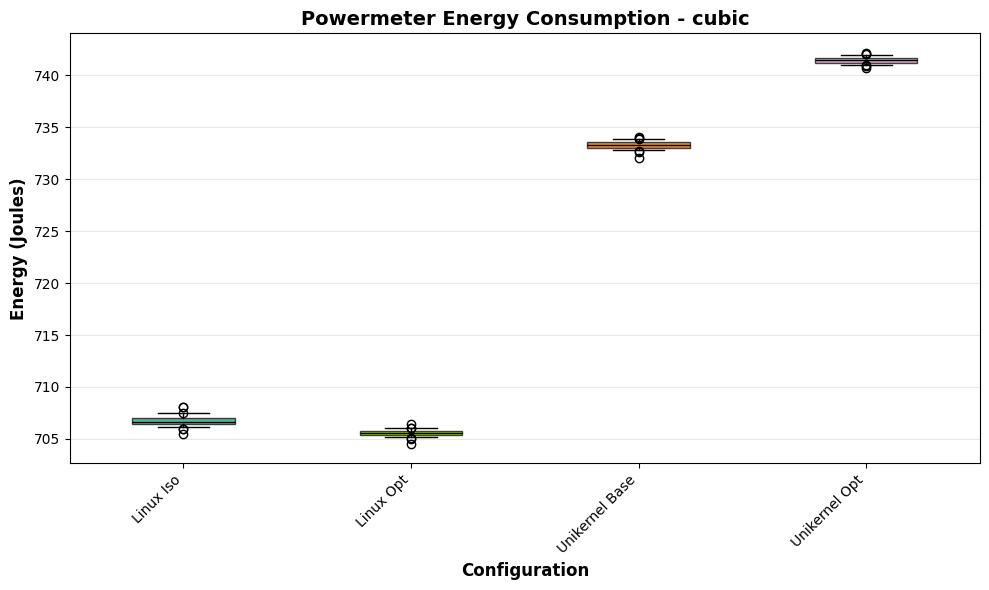

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1022636604.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/powermeter/boxplot_powermeter_dijkstra.png


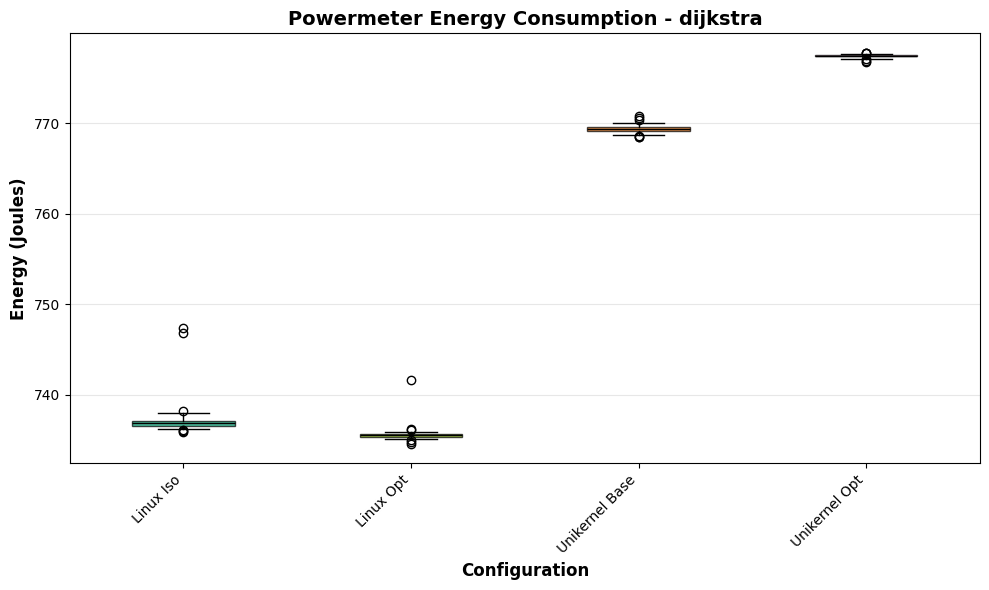

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1022636604.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/powermeter/boxplot_powermeter_fdct.png


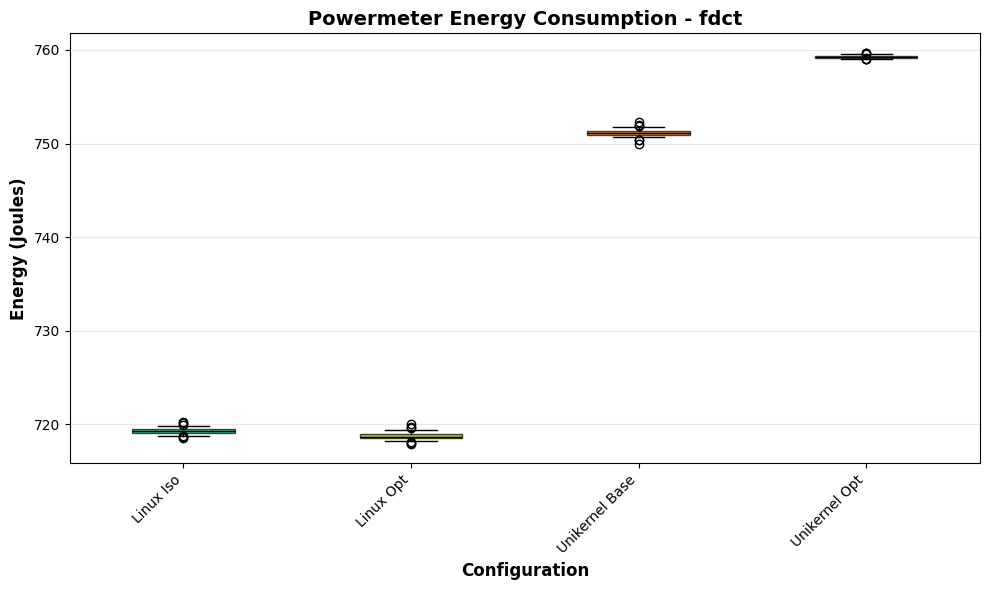

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1022636604.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/powermeter/boxplot_powermeter_fir.png


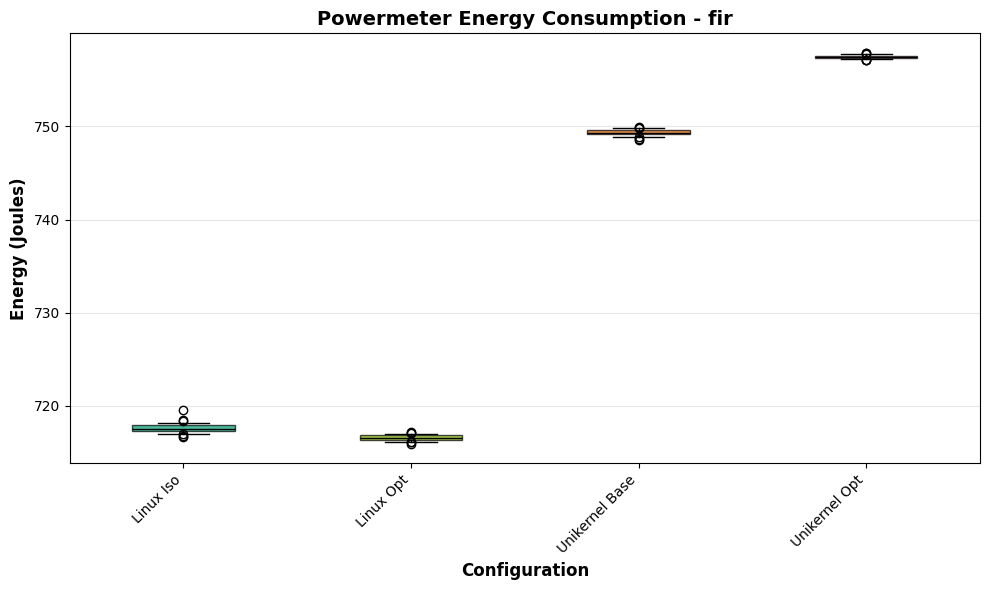

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1022636604.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/powermeter/boxplot_powermeter_matmult-float.png


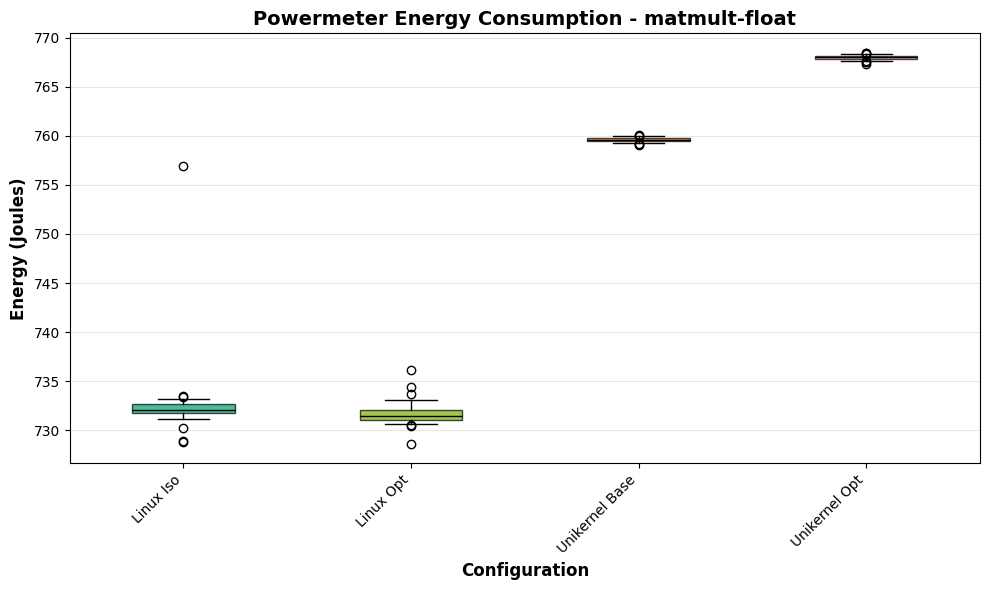

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1022636604.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/powermeter/boxplot_powermeter_matmult-int.png


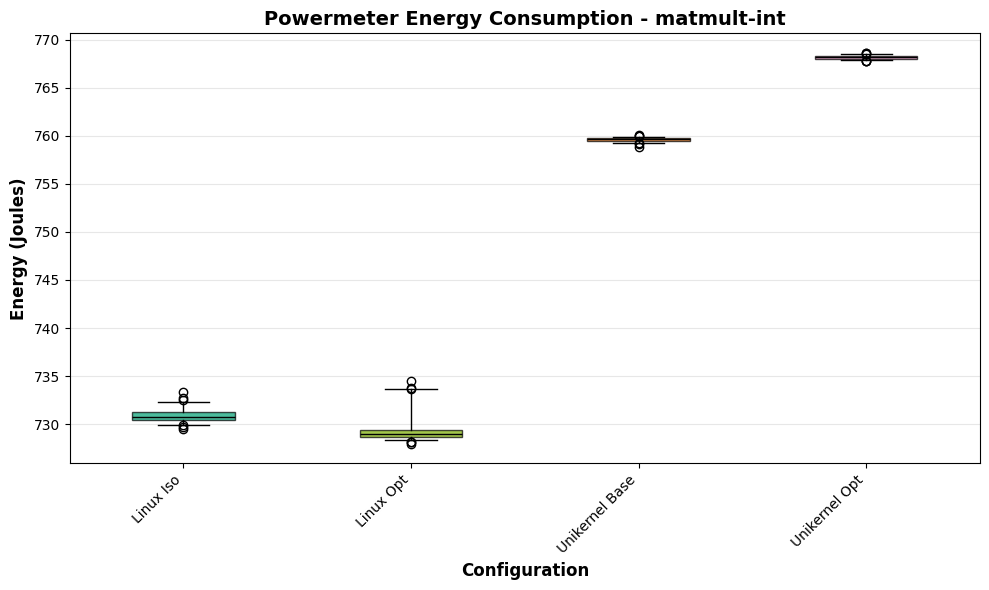

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1022636604.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/powermeter/boxplot_powermeter_nettle-sha256.png


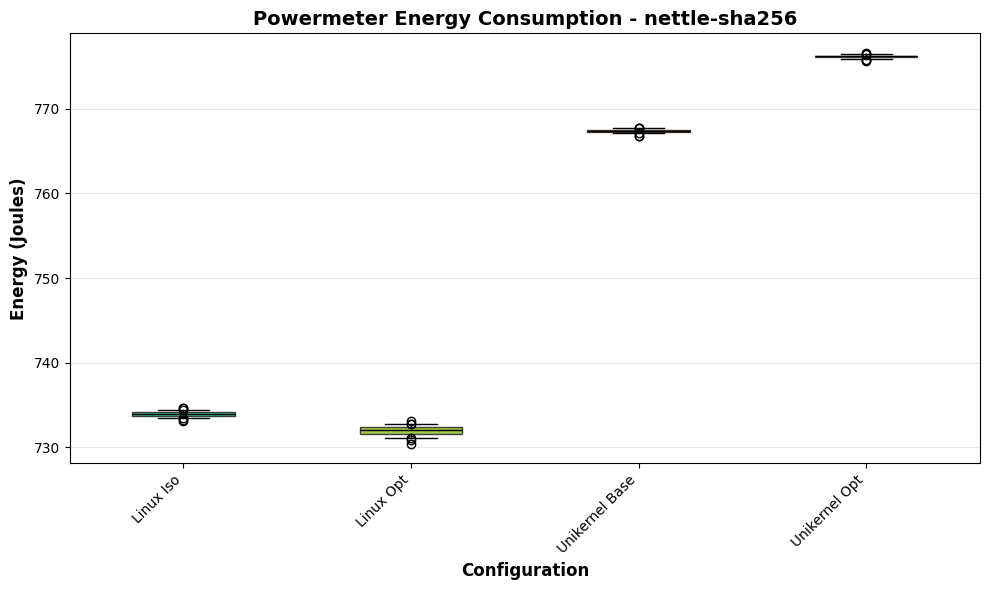

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1022636604.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/powermeter/boxplot_powermeter_rijndael.png


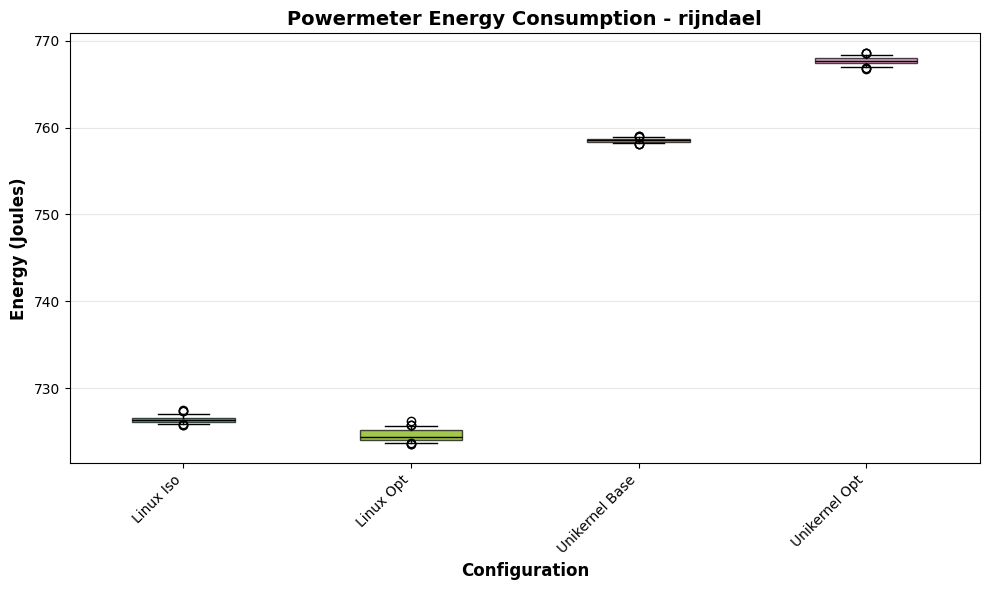

In [13]:
# Boxplot for powermeter energy consumption per benchmark
# One plot per benchmark, showing all configurations

plot_df = energy_df[
    (energy_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on') &
    ~((energy_df['config'] == 'base_linux') & (energy_df['benchmark'] == 'crc32'))
] .copy()

# Get unique benchmarks
benchmarks = sorted([b for b in plot_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    # 'naive_linux',
    # 'base_linux',
    'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys() ]

# Configuration colors
config_colors = {
    'naive_linux': '#56B4E9',
    'base_linux': '#0072B2',
    'optimized_linux_iso_eist_c-state_off': '#009E73',
    'optimized_linux_wo_iso_eist_c-state_off': '#7CAE00',
    'base_unikernel': '#D55E00',
    'optimized_unikernel': '#CC79A7'
}

# Create output directory
output_dir = Path('boxplots/powermeter')
output_dir.mkdir(parents=True, exist_ok=True)

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    config_list = []
    
    for config_name in configs:
        bench_data = []
        
        # Get powermeter data for this config and benchmark
        if config_name in powermeter_data and benchmark in powermeter_data[config_name]:
            for iteration, pm_df in powermeter_data[config_name][benchmark].items():
                if len(pm_df) < 2:
                    continue
                
                time_span_s = pc_bench.iloc[iteration]['cpu_cycles'] / 3.1e9  # Convert cycles to seconds at 3.1 GHz
                avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                energy_j = avg_power_w * time_span_s
                bench_data.append(energy_j)
        
        if bench_data:
            data_to_plot.append(bench_data)
            labels.append(config_labels.get(config_name, config_name))
            config_list.append(config_name)
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))
        
        # Customize boxplot appearance with configuration colors
        for patch, config_name in zip(bp['boxes'], config_list):
            patch.set_facecolor(config_colors.get(config_name, '#7f7f7f'))
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
        ax.set_title(f'Powermeter Energy Consumption - {benchmark}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.xticks(rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        
        # Save figure
        filename = output_dir / f'boxplot_powermeter_{benchmark}.png'
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"Saved: {filename}")
        
        plt.show()

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/2836101389.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/time/boxplot_time_crc32.png


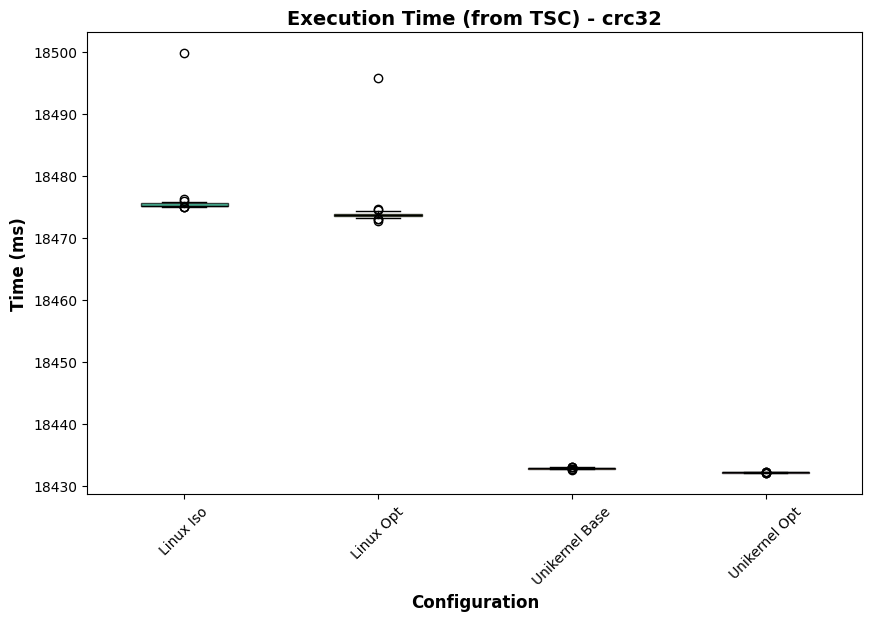

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/2836101389.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/time/boxplot_time_cubic.png


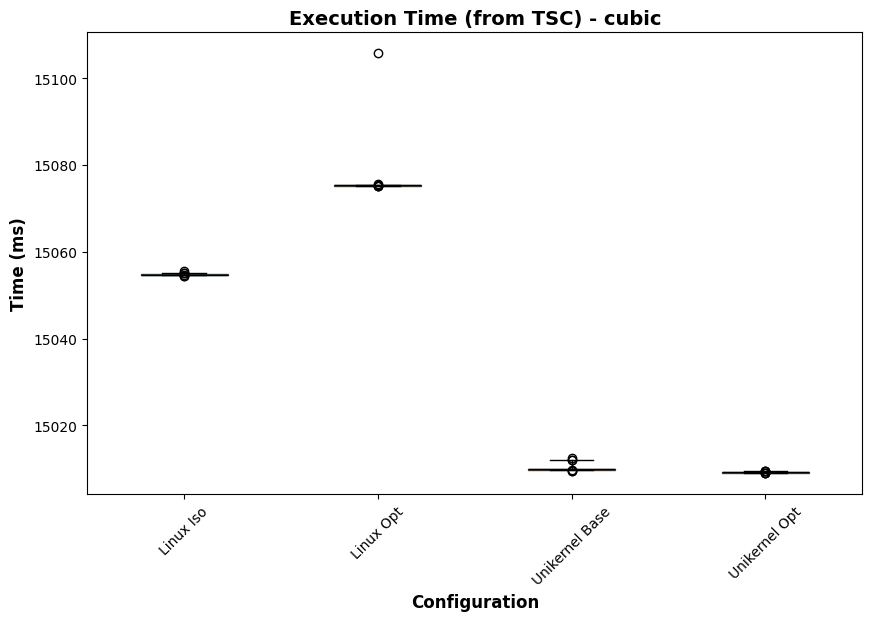

Saved: boxplots/time/boxplot_time_dijkstra.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/2836101389.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


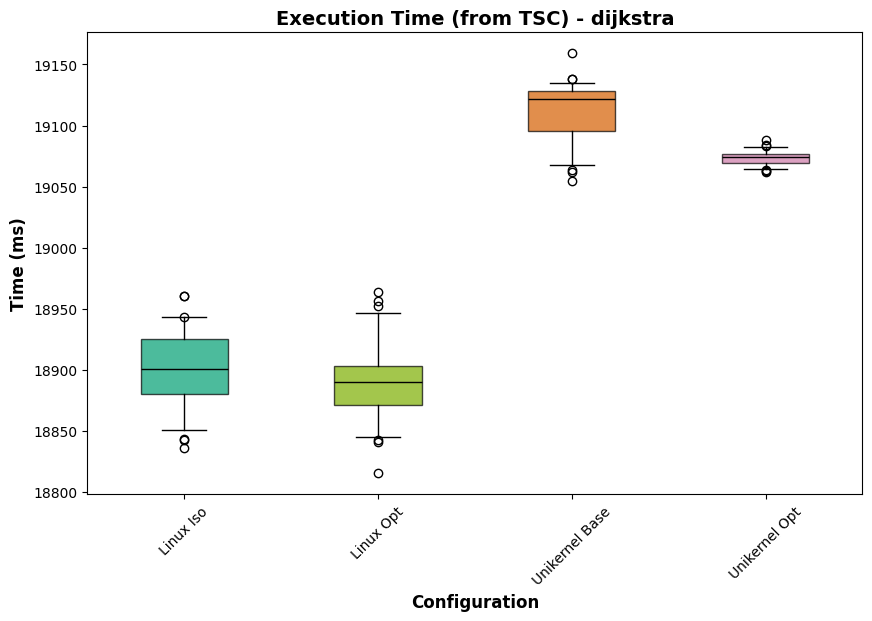

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/2836101389.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/time/boxplot_time_fdct.png


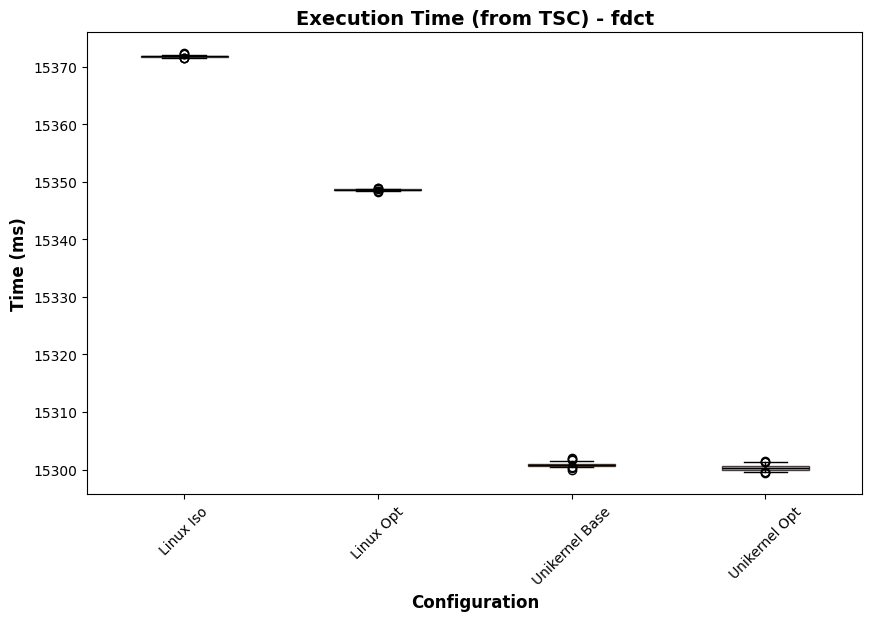

Saved: boxplots/time/boxplot_time_fir.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/2836101389.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


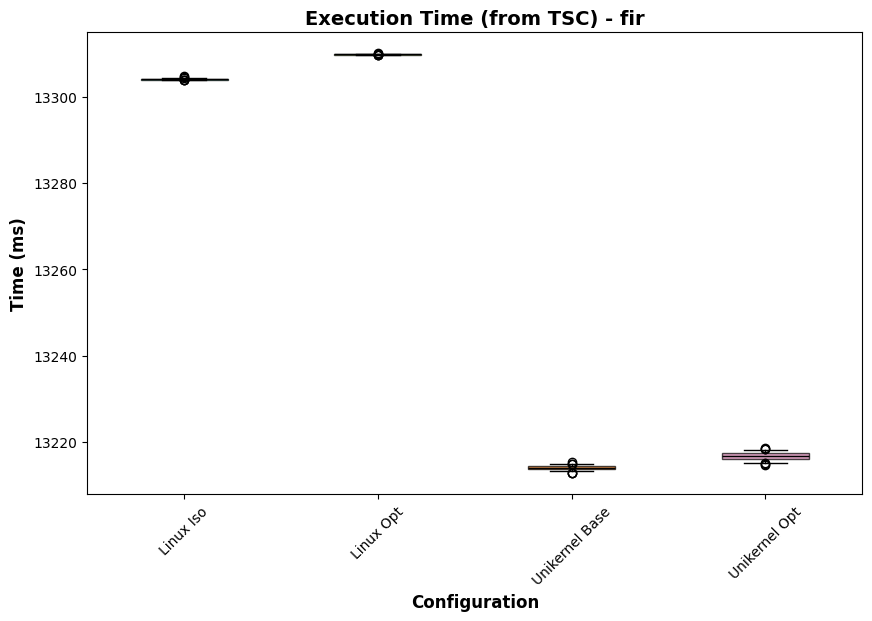

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/2836101389.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/time/boxplot_time_matmult-float.png


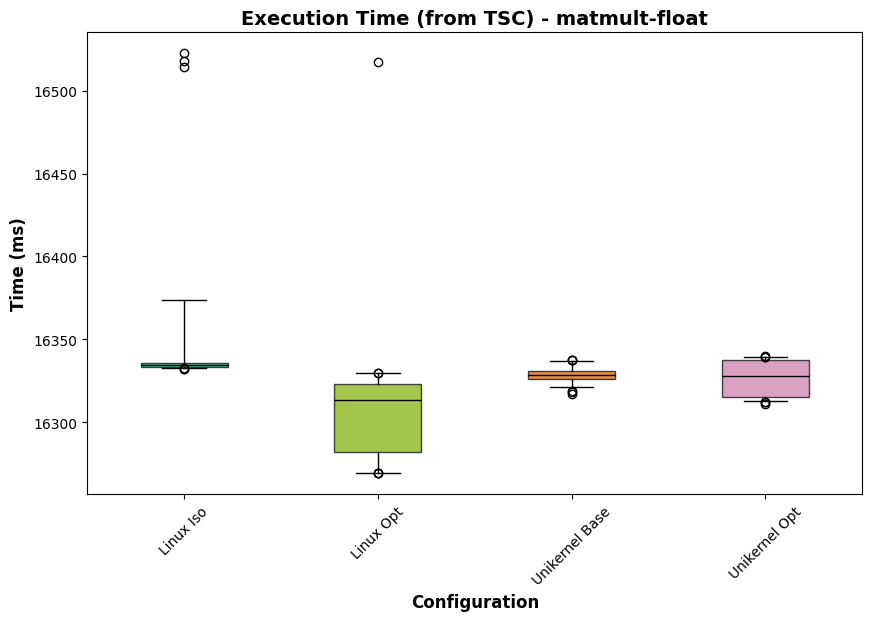

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/2836101389.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/time/boxplot_time_matmult-int.png


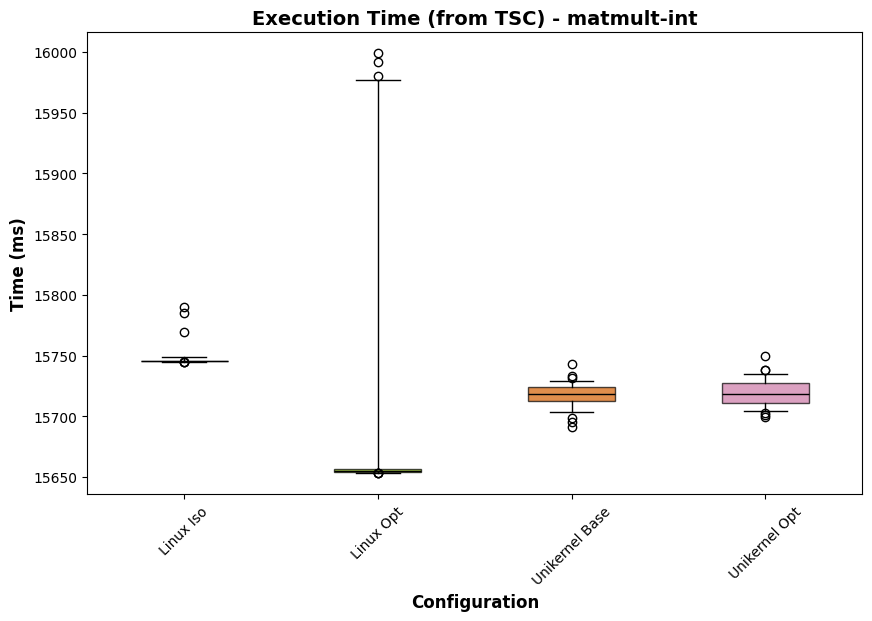

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/2836101389.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/time/boxplot_time_nettle-sha256.png


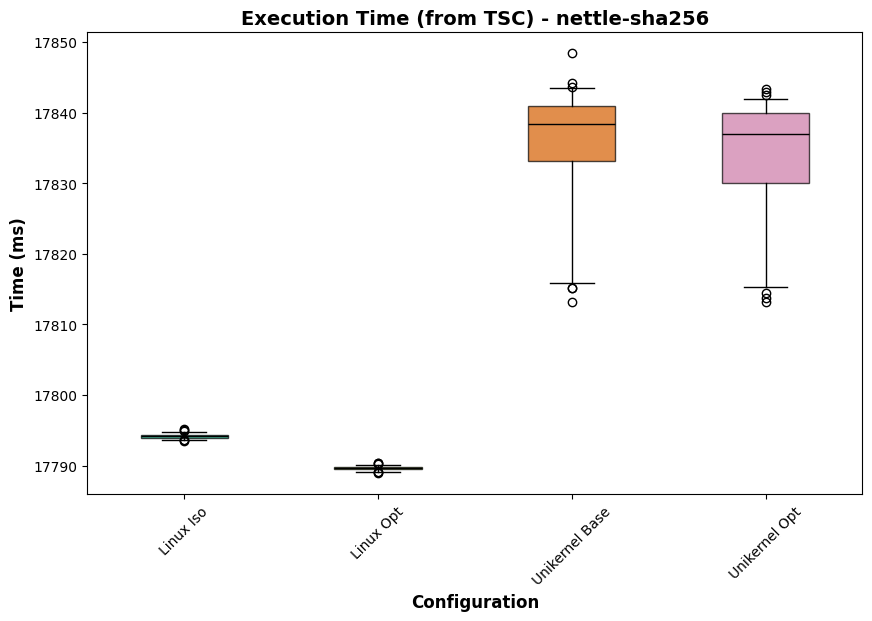

Saved: boxplots/time/boxplot_time_rijndael.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/2836101389.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


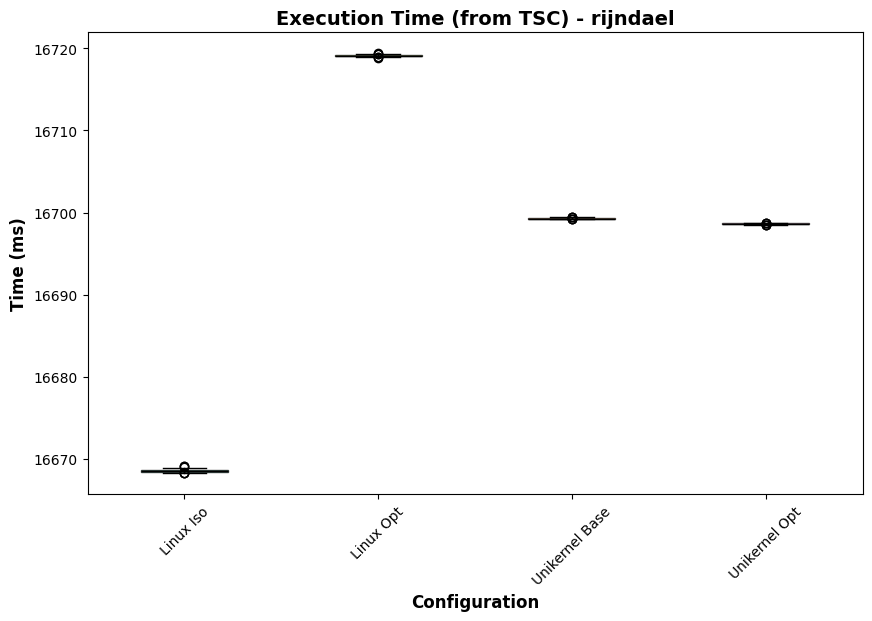


Coefficient of Variation (CV) for Execution Time


Configuration  Linux Iso  Linux Opt  Unikernel Base  Unikernel Opt
Benchmark                                                         
crc32           0.018557   0.016804        0.000462       0.000372
cubic           0.001344   0.028232        0.004651       0.000959
dijkstra        0.155499   0.165082        0.128695       0.030265
fdct            0.001161   0.000775        0.002443       0.003246
fir             0.001217   0.000670        0.004365       0.007057
matmult-float   0.268223   0.228408        0.027810       0.068763
matmult-int     0.056065   0.574474        0.063187       0.069970
nettle-sha256   0.002150   0.001808        0.048632       0.048252
rijndael        0.001244   0.000673        0.000582       0.000462



In [14]:
# Boxplot for execution time per benchmark
# One plot per benchmark, showing all configurations

plot_df = energy_df[
    (energy_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on') &
    ~((energy_df['config'] == 'base_linux') & (energy_df['benchmark'] == 'crc32'))
] .copy()

# Get unique benchmarks
benchmarks = sorted([b for b in plot_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    # 'naive_linux',
    # 'base_linux',
    'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys() and c != 'optimized_linux_wo_iso_eist_c-state_on']

# Configuration colors
config_colors = {
    # 'naive_linux': '#56B4E9',
    # 'base_linux': '#0072B2',
    'optimized_linux_iso_eist_c-state_off': '#009E73',
    'optimized_linux_wo_iso_eist_c-state_off': '#7CAE00',
    'base_unikernel': '#D55E00',
    'optimized_unikernel': '#CC79A7'
}

# Create output directory
output_dir = Path('boxplots/time')
output_dir.mkdir(parents=True, exist_ok=True)

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    config_list = []
    
    for config_name in configs:
        if config_name not in pc_data:
            continue
        
        pc_df = pc_data[config_name]
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 0:
            # Calculate time in ms from cpu_cycles using base frequency of 3.1 GHz
            # time (ms) = cycles / (3.1 × 10^9 Hz) × 1000 = cycles / 3.1e6
            time_ms = pc_bench['cpu_cycles'].values / 3.1e6
            data_to_plot.append(time_ms)
            labels.append(config_labels.get(config_name, config_name))
            config_list.append(config_name)
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))
        
        # Customize boxplot appearance with configuration colors
        for patch, config_name in zip(bp['boxes'], config_list):
            patch.set_facecolor(config_colors.get(config_name, '#7f7f7f'))
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Time (ms)', fontsize=12, fontweight='bold')
        ax.set_title(f'Execution Time (from TSC) - {benchmark}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        
        # Save figure
        filename = output_dir / f'boxplot_time_{benchmark}.png'
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"Saved: {filename}")
        
        plt.show()

# Calculate and display CV table for execution time
print("\n" + "="*80)
print("Coefficient of Variation (CV) for Execution Time")
print("="*80)

time_cv_results = []

for config_name in configs:
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    
    for benchmark in benchmarks:
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 1:
            # Calculate time in ms from cpu_cycles
            time_ms = pc_bench['cpu_cycles'].values / 3.1e6
            time_cv = (time_ms.std() / time_ms.mean()) * 100
        else:
            time_cv = None
        
        time_cv_results.append({
            'Configuration': config_labels.get(config_name, config_name),
            'Benchmark': benchmark,
            'CV (%)': time_cv
        })

# Convert to DataFrame and pivot for better display
time_cv_df = pd.DataFrame(time_cv_results)
time_cv_pivot = time_cv_df.pivot(index='Benchmark', columns='Configuration', values='CV (%)')

# Reorder columns to match config_order
time_cv_pivot = time_cv_pivot[[config_labels.get(c, c) for c in configs if config_labels.get(c, c) in time_cv_pivot.columns]]

print("\n")
print(time_cv_pivot.to_string())
print("\n" + "="*80)

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1594794226.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/pp0/boxplot_pp0_crc32.png


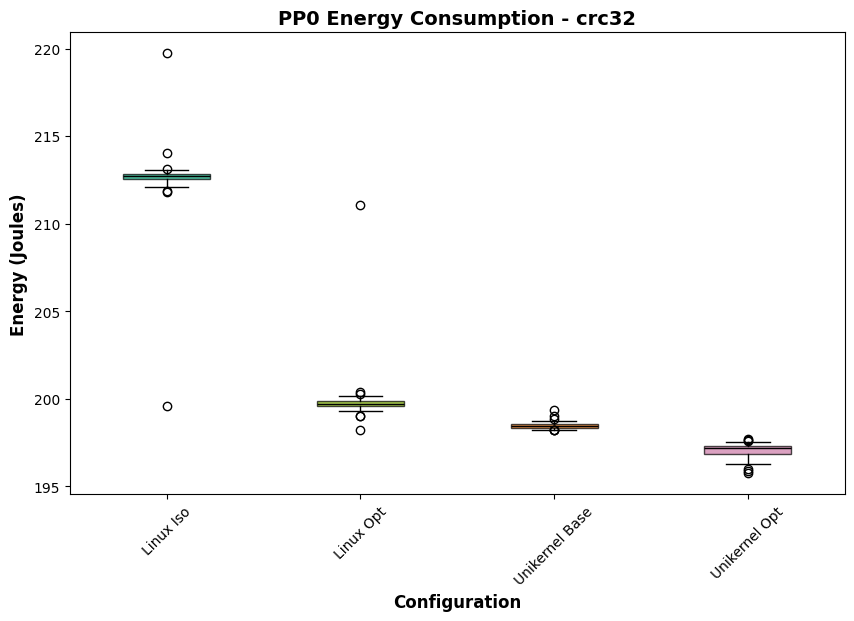

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1594794226.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/pp0/boxplot_pp0_cubic.png


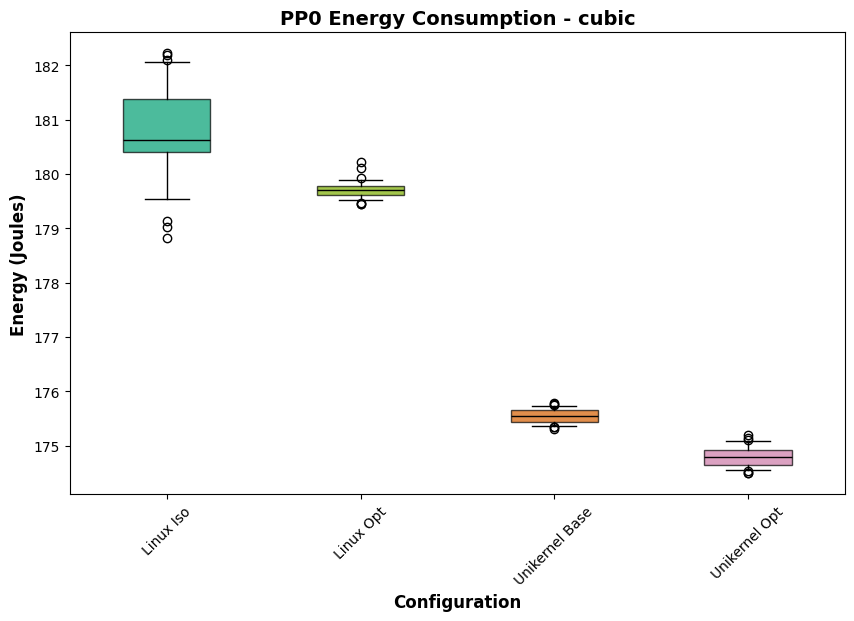

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1594794226.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/pp0/boxplot_pp0_dijkstra.png


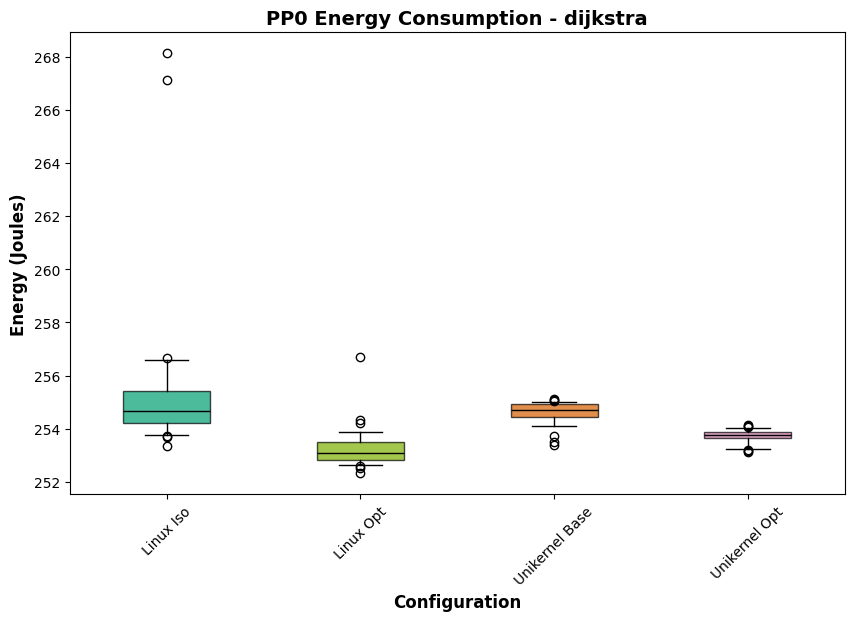

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1594794226.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/pp0/boxplot_pp0_fdct.png


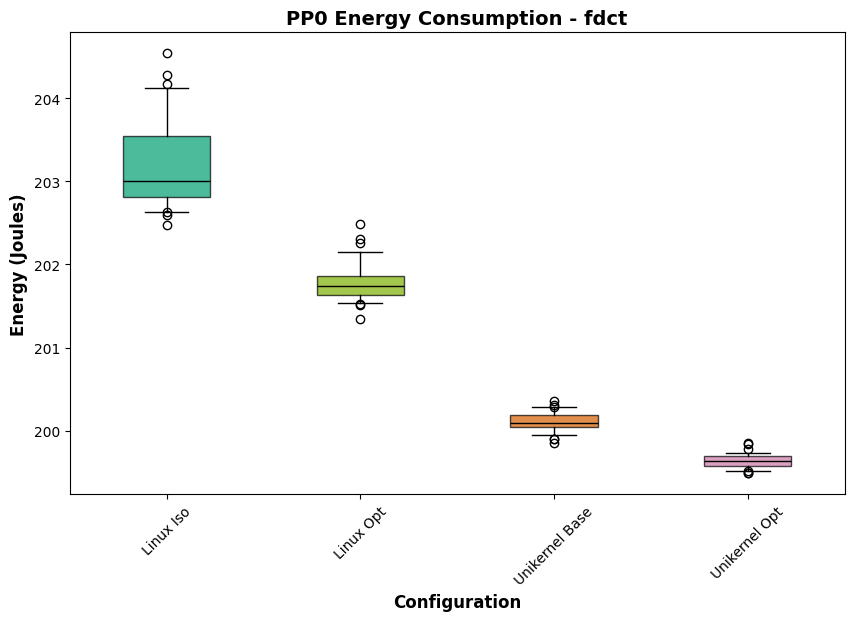

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1594794226.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/pp0/boxplot_pp0_fir.png


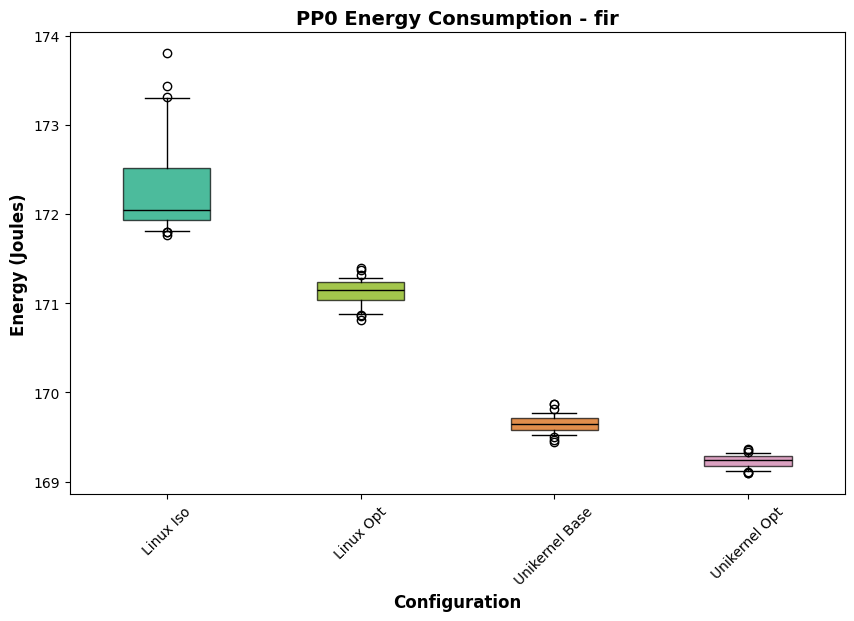

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1594794226.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/pp0/boxplot_pp0_matmult-float.png


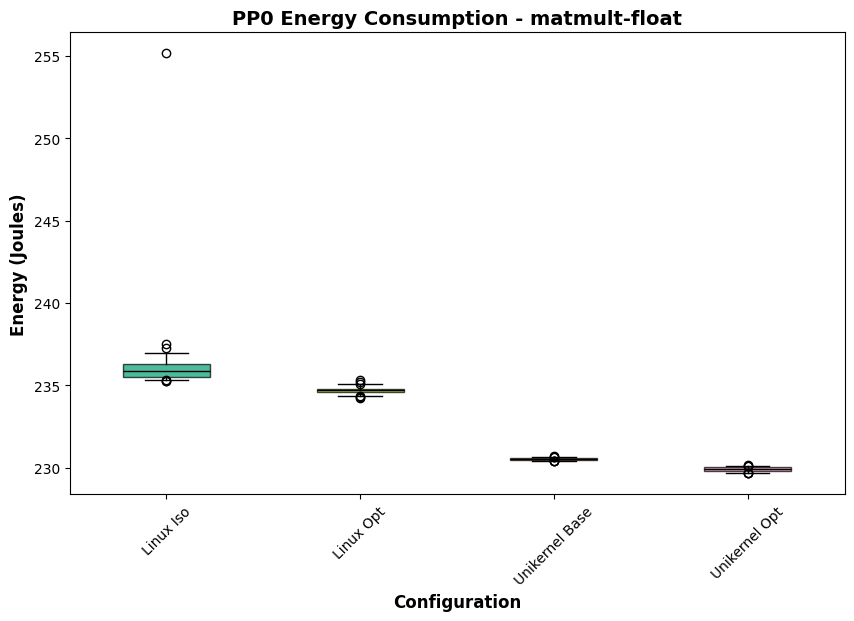

Saved: boxplots/pp0/boxplot_pp0_matmult-int.png


/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1594794226.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


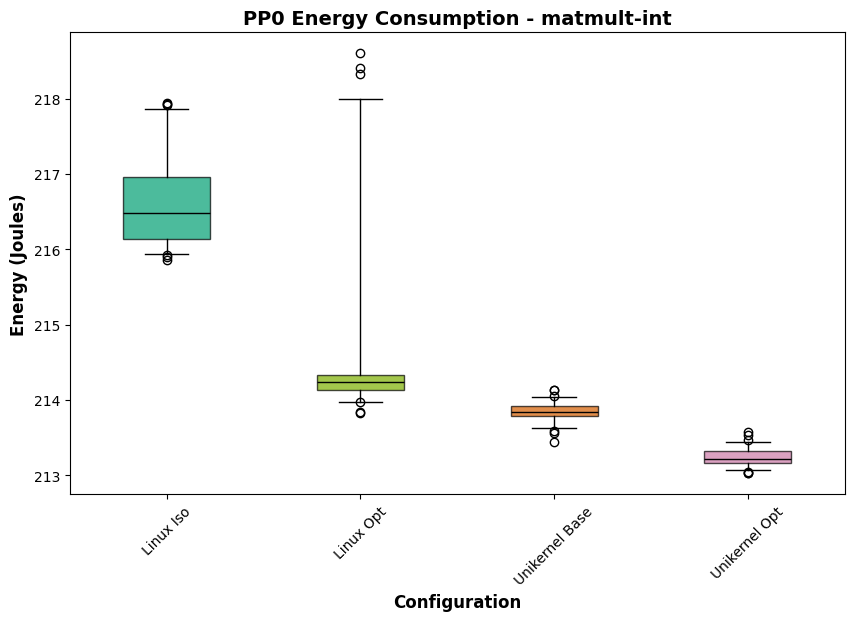

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1594794226.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/pp0/boxplot_pp0_nettle-sha256.png


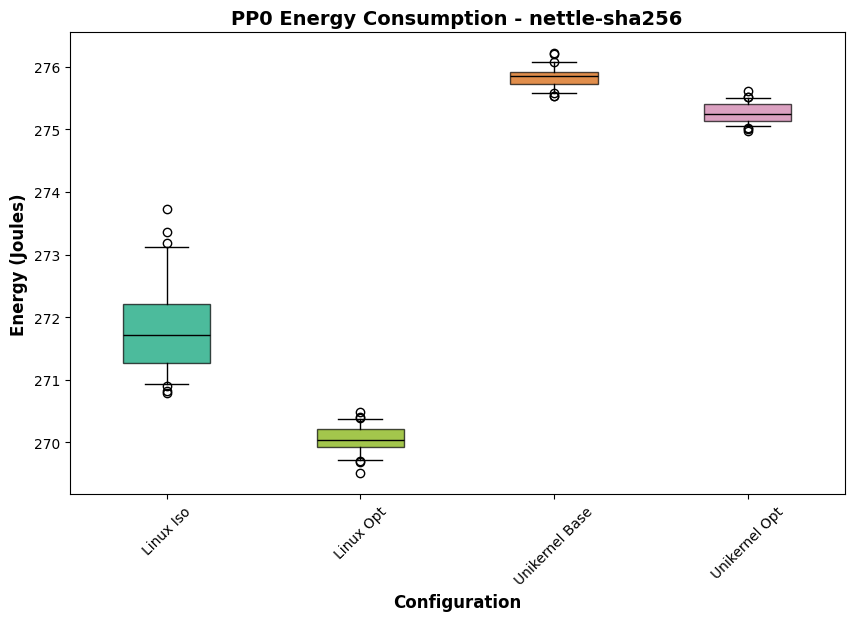

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_94687/1594794226.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))


Saved: boxplots/pp0/boxplot_pp0_rijndael.png


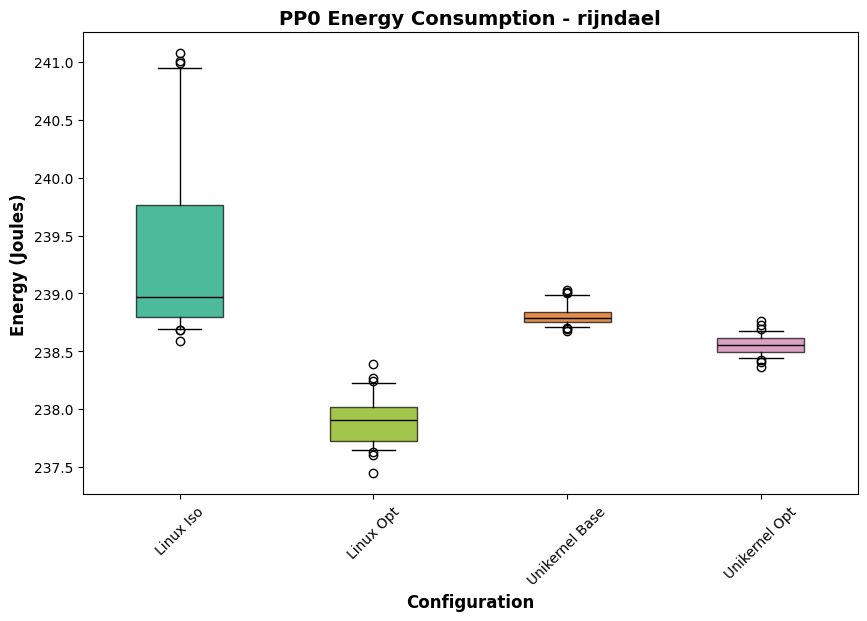


Coefficient of Variation (CV) for PP0 Energy


Configuration  Linux Iso  Linux Opt  Unikernel Base  Unikernel Opt
Benchmark                                                         
crc32           1.001091   0.817100        0.109641       0.229914
cubic           0.436380   0.079777        0.073187       0.103205
dijkstra        1.030598   0.255658        0.146219       0.093827
fdct            0.254005   0.109144        0.053633       0.040041
fir             0.306470   0.082107        0.056778       0.040793
matmult-float   1.160613   0.097878        0.036745       0.059369
matmult-int     0.282901   0.527066        0.065602       0.057654
nettle-sha256   0.266737   0.081169        0.053783       0.056079
rijndael        0.298983   0.085311        0.034663       0.034660



In [15]:
# Boxplot for PP0 energy consumption per benchmark with CV table
# One plot per benchmark, showing all configurations

plot_df = energy_df[
    (energy_df['config'] != 'optimized_linux_wo_iso_eist_c-state_on') &
    ~((energy_df['config'] == 'base_linux') & (energy_df['benchmark'] == 'crc32'))
] .copy()

# Get unique benchmarks
benchmarks = sorted([b for b in plot_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    # 'naive_linux',
    # 'base_linux',
    'optimized_linux_iso_eist_c-state_off',
    'optimized_linux_wo_iso_eist_c-state_off',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys() and c != 'optimized_linux_wo_iso_eist_c-state_on']

# Configuration colors
config_colors = {
    'naive_linux': '#56B4E9',
    'base_linux': '#0072B2',
    'optimized_linux_iso_eist_c-state_off': '#009E73',
    'optimized_linux_wo_iso_eist_c-state_off': '#7CAE00',
    'base_unikernel': '#D55E00',
    'optimized_unikernel': '#CC79A7'
}

# Create output directory
output_dir = Path('boxplots/pp0')
output_dir.mkdir(parents=True, exist_ok=True)

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    config_list = []
    
    for config_name in configs:
        if config_name not in pc_data:
            continue
        
        pc_df = pc_data[config_name]
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 0:
            data_to_plot.append(pc_bench['pp0_joules'].values)
            labels.append(config_labels.get(config_name, config_name))
            config_list.append(config_name)
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95), medianprops=dict(color='black', linewidth=1))
        
        # Customize boxplot appearance with configuration colors
        for patch, config_name in zip(bp['boxes'], config_list):
            patch.set_facecolor(config_colors.get(config_name, '#7f7f7f'))
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
        ax.set_title(f'PP0 Energy Consumption - {benchmark}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        
        # Save figure
        filename = output_dir / f'boxplot_pp0_{benchmark}.png'
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"Saved: {filename}")
        
        plt.show()

# Calculate and display CV table for PP0 energy
print("\n" + "="*80)
print("Coefficient of Variation (CV) for PP0 Energy")
print("="*80)

pp0_energy_cv_results = []

for config_name in configs:
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    
    for benchmark in benchmarks:
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 1:
            # Calculate PP0 energy CV
            pp0_energy = pc_bench['pp0_joules'].values
            pp0_energy_cv = (pp0_energy.std() / pp0_energy.mean()) * 100
        else:
            pp0_energy_cv = None
        
        pp0_energy_cv_results.append({
            'Configuration': config_labels.get(config_name, config_name),
            'Benchmark': benchmark,
            'CV (%)': pp0_energy_cv
        })

# Convert to DataFrame and pivot for better display
pp0_energy_cv_df = pd.DataFrame(pp0_energy_cv_results)
pp0_energy_cv_pivot = pp0_energy_cv_df.pivot(index='Benchmark', columns='Configuration', values='CV (%)')

# Reorder columns to match config_order
pp0_energy_cv_pivot = pp0_energy_cv_pivot[[config_labels.get(c, c) for c in configs if config_labels.get(c, c) in pp0_energy_cv_pivot.columns]]

print("\n")
print(pp0_energy_cv_pivot.to_string())
print("\n" + "="*80)

In [16]:
# Calculate total execution time for each configuration
print("Total execution time per configuration:")
print("=" * 60)

for config_name in subdirs.keys():
    # Skip naive_linux
    if config_name == 'naive_linux':
        continue
        
    if config_name not in pc_data:
        print(f"{config_labels.get(config_name, config_name)}: No data available")
        continue
    
    pc_df = pc_data[config_name]
    display_name = config_labels.get(config_name, config_name)
    
    # Sum all execution times
    total_time_ms = pc_df['cooldown_ms'].sum()
    total_time_s = total_time_ms / 1000
    total_time_min = total_time_s / 60
    
    # Count number of measurements
    num_measurements = len(pc_df)
    
    print(f"\n{display_name}:")
    print(f"  Total time: {total_time_ms:,.2f} ms ({total_time_s:,.2f} s / {total_time_min:,.2f} min)")
    print(f"  Number of measurements: {num_measurements}")
    print(f"  Average time per measurement: {total_time_ms/num_measurements:.2f} ms")


Total execution time per configuration:

Linux Base:
  Total time: 39,244.00 ms (39.24 s / 0.65 min)
  Number of measurements: 450
  Average time per measurement: 87.21 ms

Unikernel Base:
  Total time: 7,438.00 ms (7.44 s / 0.12 min)
  Number of measurements: 451
  Average time per measurement: 16.49 ms

Linux Iso:
  Total time: 7,270.87 ms (7.27 s / 0.12 min)
  Number of measurements: 450
  Average time per measurement: 16.16 ms

Linux Opt:
  Total time: 10,265.84 ms (10.27 s / 0.17 min)
  Number of measurements: 450
  Average time per measurement: 22.81 ms

Unikernel Opt:
  Total time: 5,180.00 ms (5.18 s / 0.09 min)
  Number of measurements: 450
  Average time per measurement: 11.51 ms


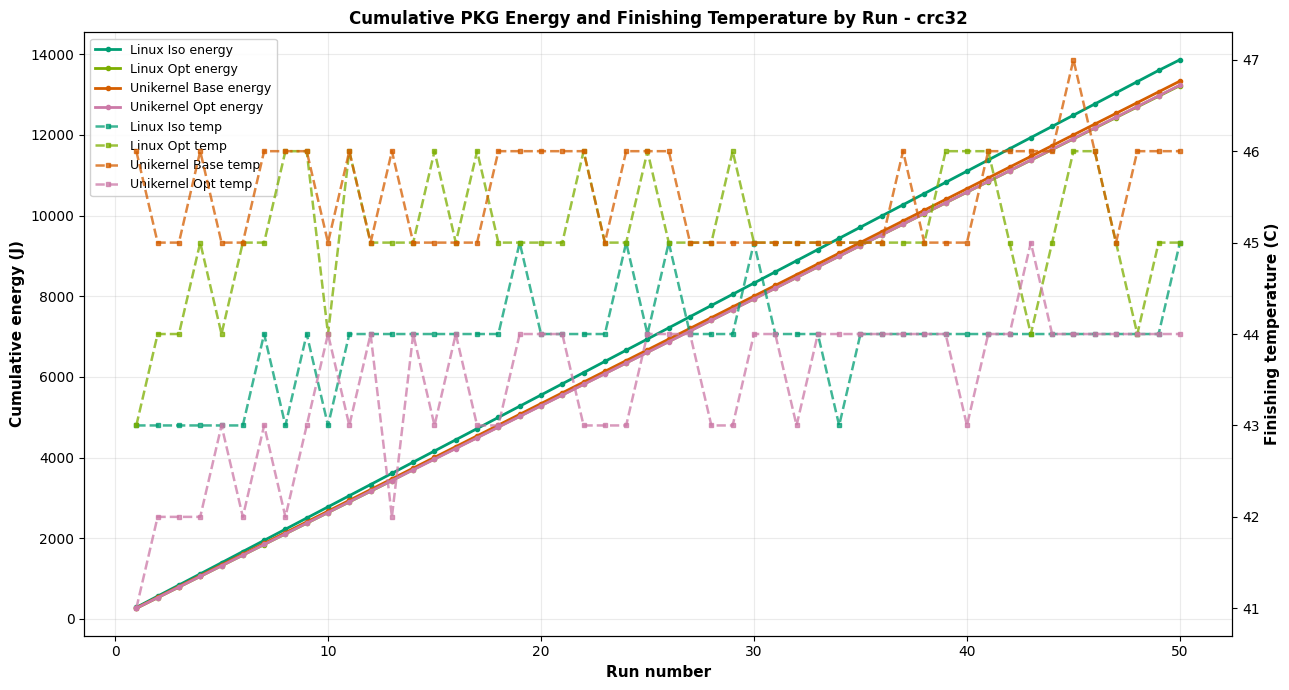

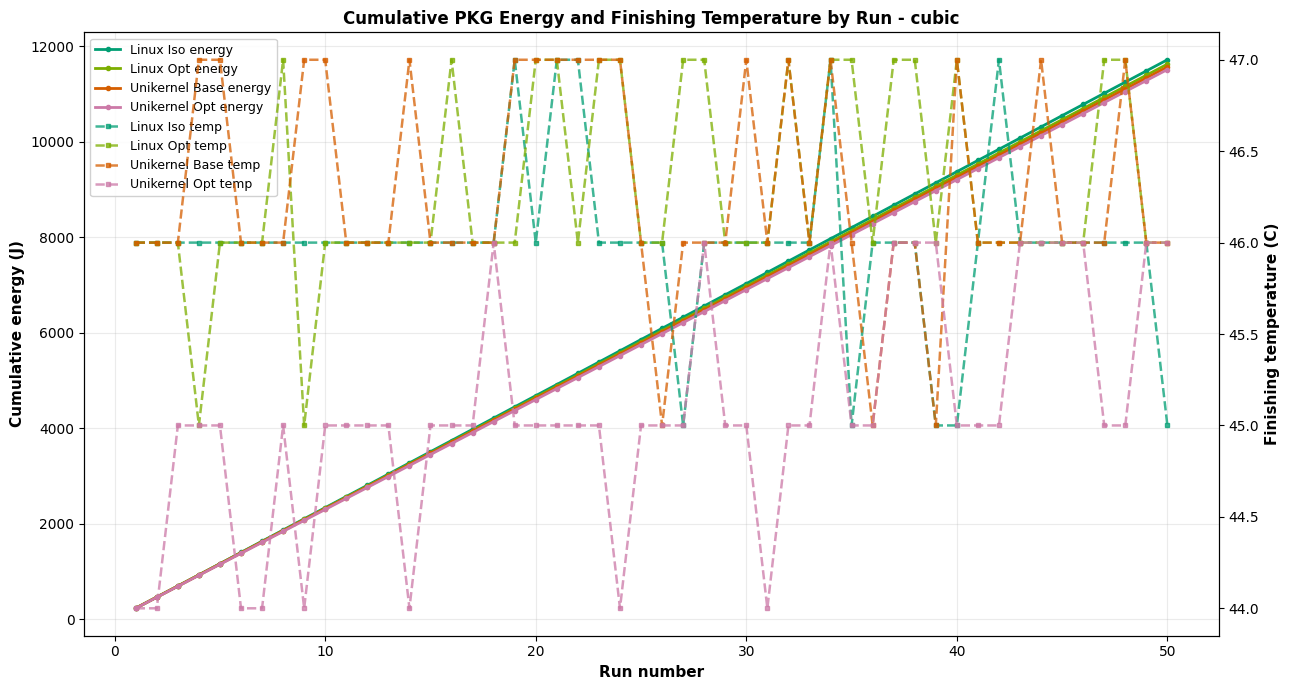

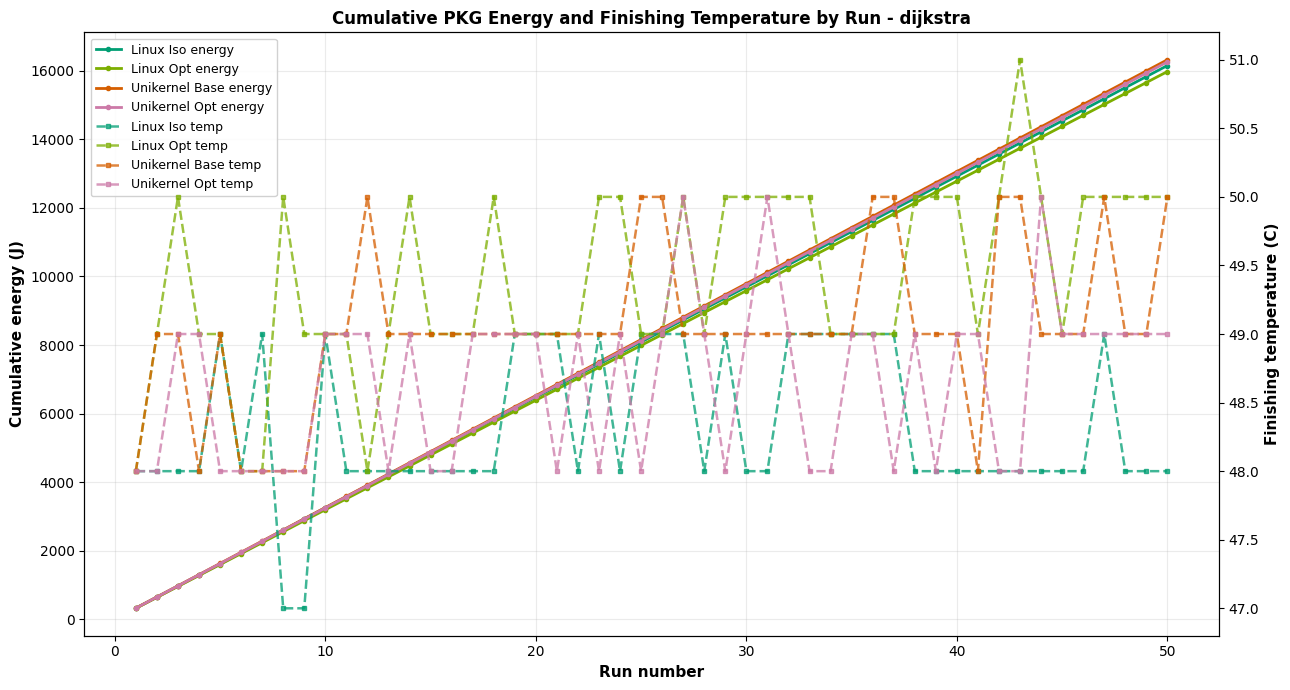

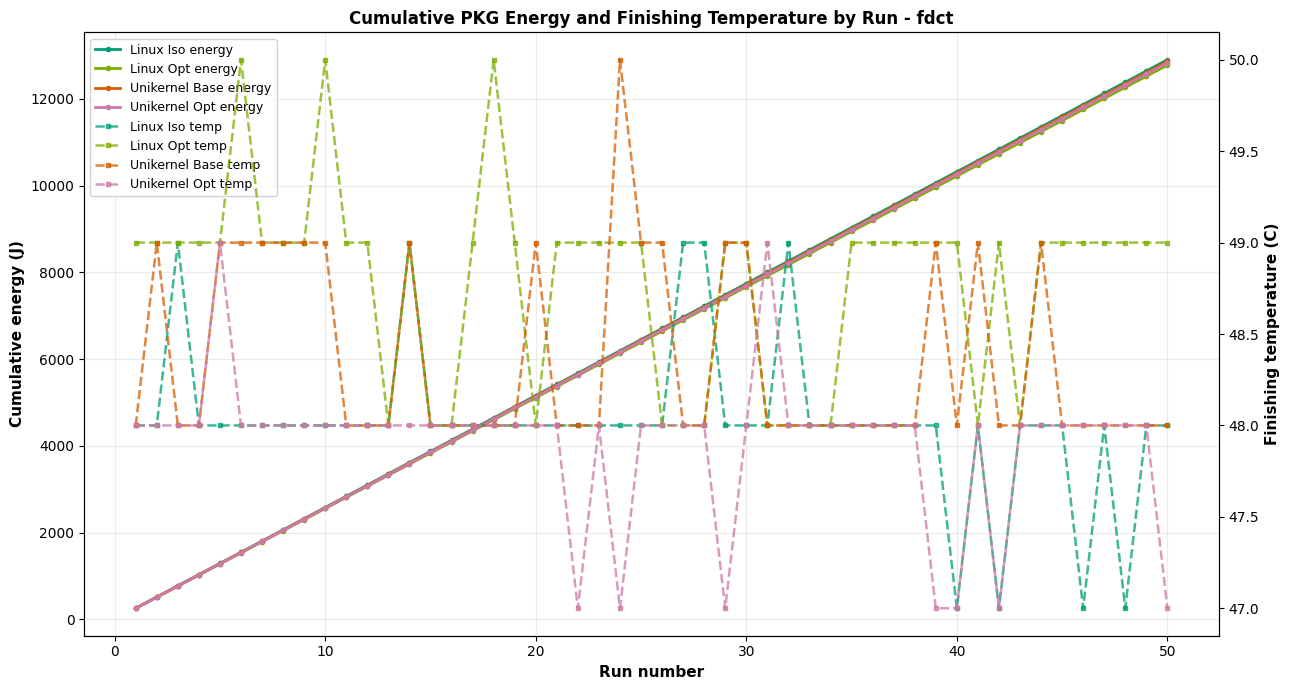

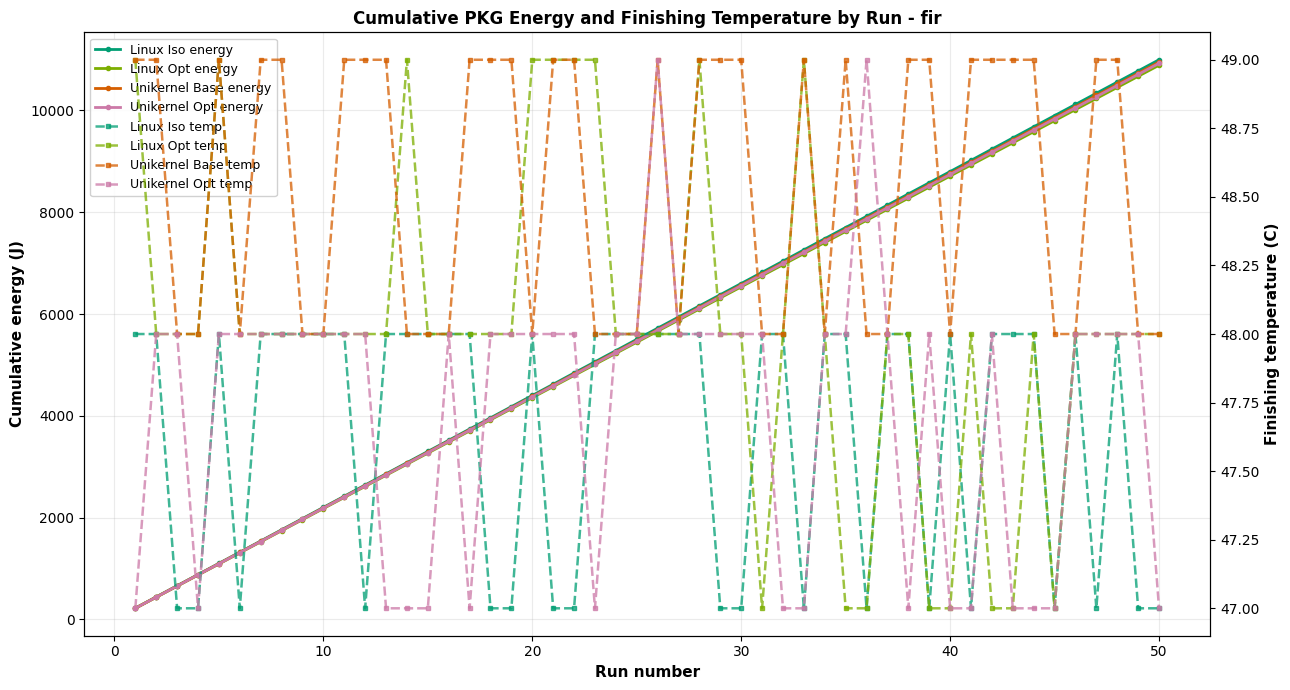

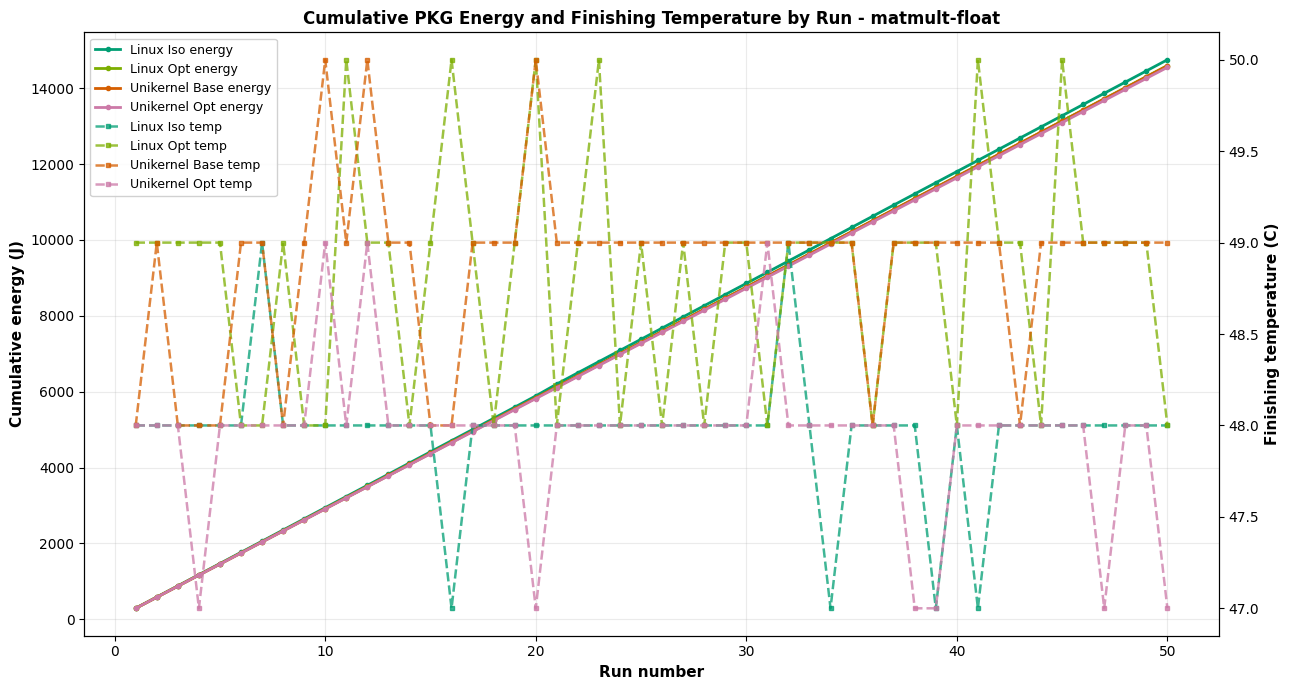

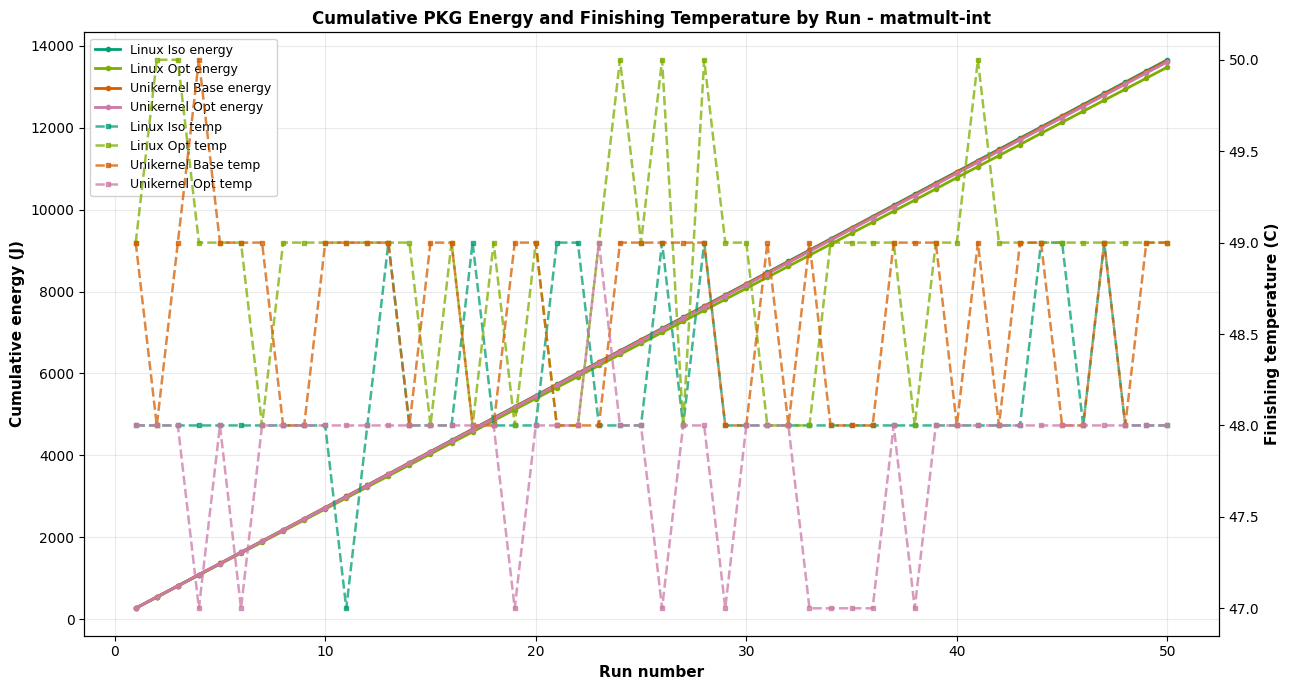

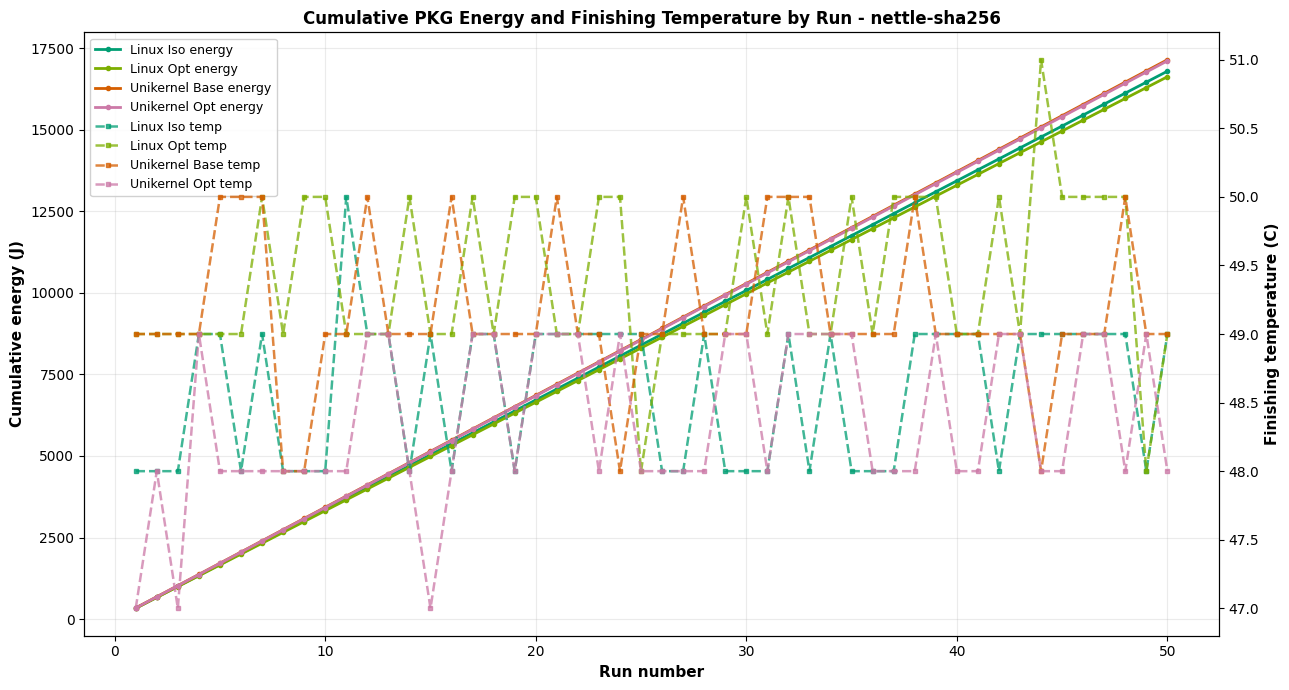

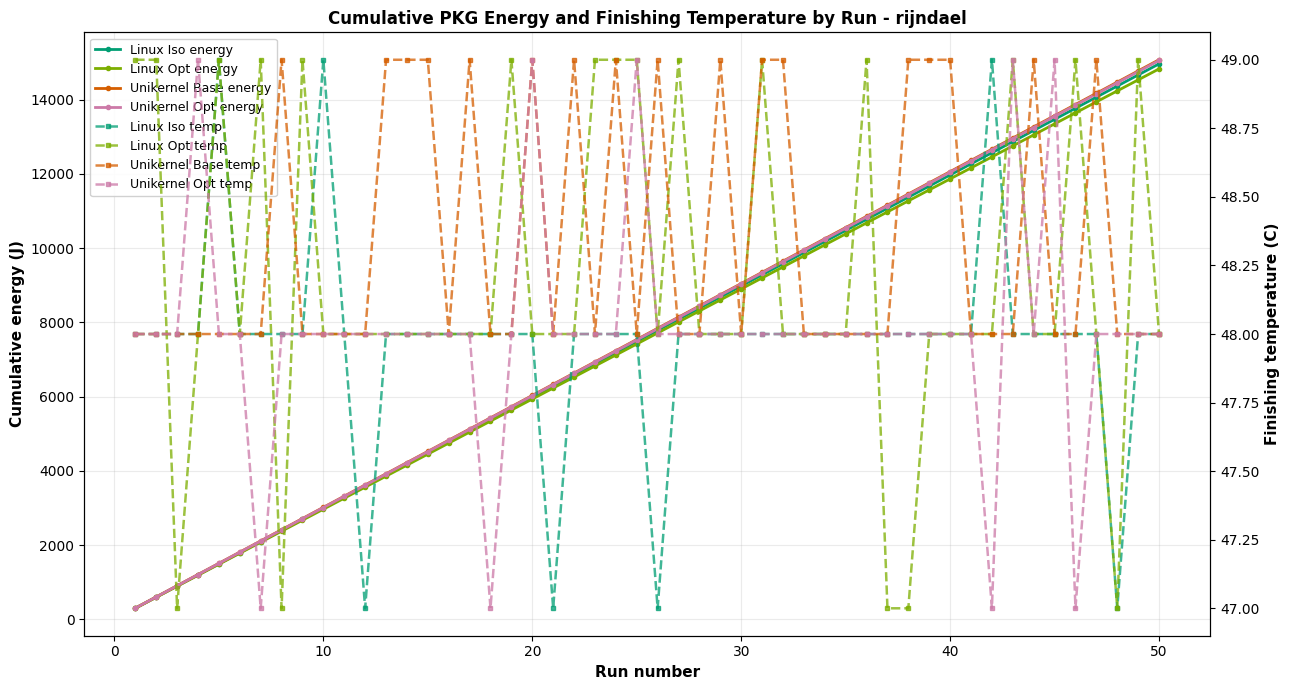

In [17]:
# Cumulative PKG energy by benchmark, with temperature shown on a second axis
if 'pc_data' not in globals() or not pc_data:
    print('pc_data is not loaded. Run the data-loading cells first.')
else:
    required = {'benchmark', 'pp0_joules'}
    temp_candidates = ['pkg_temp_after', 'temp_after']

    # Keep a consistent display order across all benchmark plots.
    config_order = [
        # 'naive_linux',
        # 'base_linux',
        'optimized_linux_iso_eist_c-state_off',
        'optimized_linux_wo_iso_eist_c-state_off',
        'base_unikernel',
        'optimized_unikernel'
    ]
    ordered_configs = [c for c in config_order if c in pc_data]
    remaining_configs = sorted([c for c in pc_data.keys() if c not in ordered_configs])
    all_configs = ordered_configs 

    # Build benchmark list across all configs that have required columns.
    benchmark_set = set()
    for config_name in all_configs:
        pc_df = pc_data[config_name]
        if required.issubset(pc_df.columns):
            benchmark_set.update(pc_df['benchmark'].dropna().unique())
    benchmarks = sorted(benchmark_set)

    if not benchmarks:
        print('No benchmark data found with required columns.')
    else:
        for benchmark in benchmarks:
            fig, ax_energy = plt.subplots(figsize=(13, 7))
            ax_temp = ax_energy.twinx()
            energy_handles = []
            temp_handles = []
            any_energy_series = False
            any_temp_series = False

            for config_name in all_configs:
                pc_df = pc_data[config_name]
                if not required.issubset(pc_df.columns):
                    continue

                bench_df = pc_df[pc_df['benchmark'] == benchmark].reset_index(drop=True)
                if len(bench_df) == 0:
                    continue

                run_nr = np.arange(1, len(bench_df) + 1)
                cumulative_energy = bench_df['pkg_joules'].cumsum()
                line_color = config_colors.get(config_name, '#7f7f7f')
                display_name = config_labels.get(config_name, config_name)

                energy_line, = ax_energy.plot(
                    run_nr,
                    cumulative_energy,
                    linewidth=2.0,
                    marker='o',
                    markersize=3,
                    color=line_color,
                    label=f'{display_name} energy'
                )
                energy_handles.append(energy_line)
                any_energy_series = True

                temp_col = next((col for col in temp_candidates if col in bench_df.columns), None)
                if temp_col is not None:
                    temp_series = pd.to_numeric(bench_df[temp_col], errors='coerce')
                    if temp_series.notna().any():
                        temp_line, = ax_temp.plot(
                            run_nr,
                            temp_series,
                            linewidth=1.8,
                            linestyle='--',
                            marker='s',
                            markersize=3,
                            color=line_color,
                            alpha=0.75,
                            label=f'{display_name} temp'
                        )
                        temp_handles.append(temp_line)
                        any_temp_series = True

            if not any_energy_series:
                plt.close(fig)
                print(f'No data to plot for benchmark: {benchmark}')
                continue

            ax_energy.set_xlabel('Run number', fontsize=11, fontweight='bold')
            ax_energy.set_ylabel('Cumulative energy (J)', fontsize=11, fontweight='bold')
            ax_temp.set_ylabel('Finishing temperature (C)', fontsize=11, fontweight='bold')
            ax_energy.set_title(
                f'Cumulative PKG Energy and Finishing Temperature by Run - {benchmark}',
                fontsize=12,
                fontweight='bold'
            )
            ax_energy.grid(alpha=0.25)
            handles = energy_handles + temp_handles
            if handles:
                ax_energy.legend(handles, [handle.get_label() for handle in handles], loc='upper left', fontsize=9, framealpha=0.9)
            if not any_temp_series:
                ax_temp.set_ylabel('Finishing temperature (C)', fontsize=11, fontweight='bold')

            plt.tight_layout()
            plt.show()

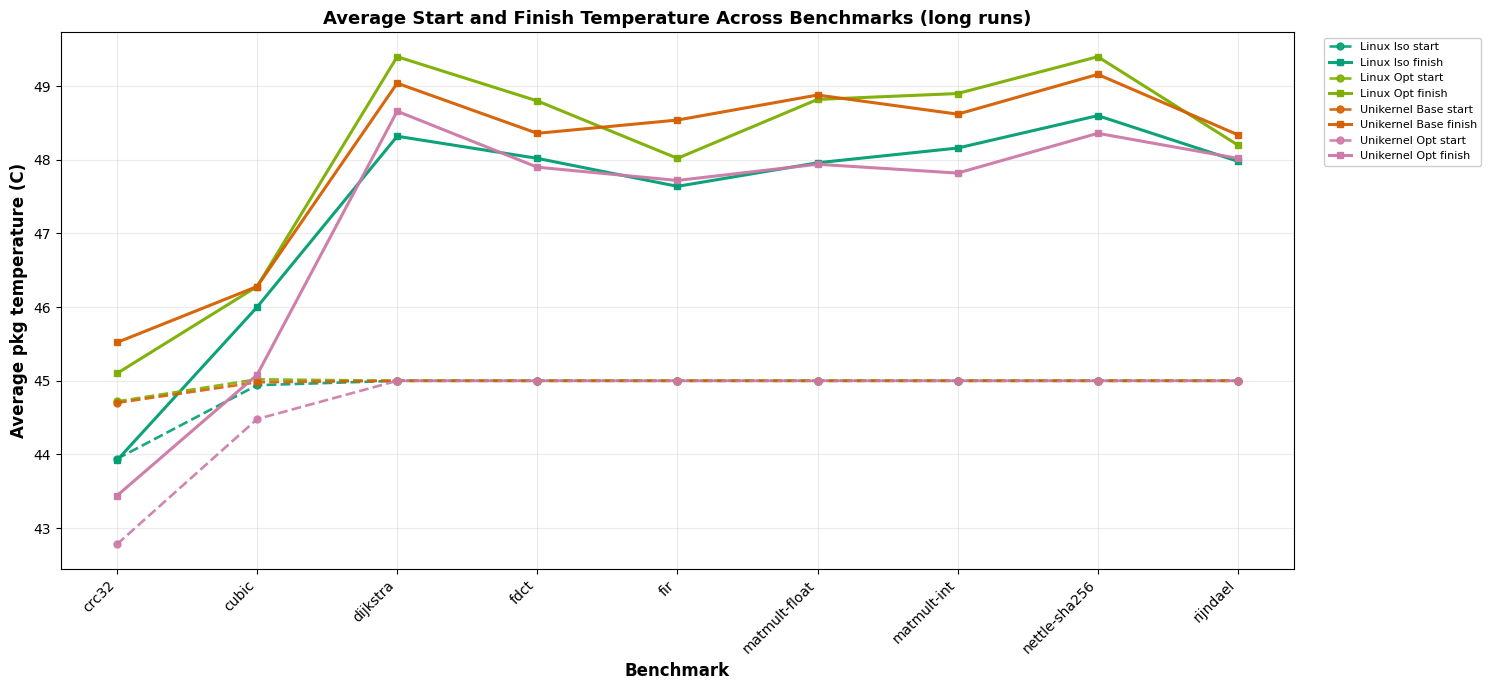

In [18]:
# Average start/finish temperature per benchmark in a single plot (hue = configuration)
if 'pc_data' not in globals() or not pc_data:
    print('pc_data is not loaded. Run the data-loading cells first.')
else:
    start_temp_candidates = ['pkg_temp_before']
    finish_temp_candidates = ['pkg_temp_after']

    preferred_order = [
        # 'naive_linux',
        # 'base_linux',
        'linux_iso',
        'linux_optimized_wo_iso',
        'optimized_linux_iso_eist_c-state_off',
        'optimized_linux_wo_iso_eist_c-state_off',
        'base_unikernel',
        'optimized_unikernel'
    ]

    ordered_configs = [c for c in preferred_order if c in pc_data]

    rows = []
    for config_name in ordered_configs:
        pc_df = pc_data.get(config_name)
        if pc_df is None or 'benchmark' not in pc_df.columns:
            continue

        start_col = next((col for col in start_temp_candidates if col in pc_df.columns), None)
        finish_col = next((col for col in finish_temp_candidates if col in pc_df.columns), None)
        if start_col is None and finish_col is None:
            continue

        for benchmark, group in pc_df.groupby('benchmark', sort=True):
            entry = {'config': config_name, 'benchmark': benchmark}
            if start_col is not None:
                entry['avg_start_temp'] = pd.to_numeric(group[start_col], errors='coerce').mean()
            if finish_col is not None:
                entry['avg_finish_temp'] = pd.to_numeric(group[finish_col], errors='coerce').mean()
            rows.append(entry)

    temp_avg_df = pd.DataFrame(rows)
    if temp_avg_df.empty:
        print('No usable temperature columns were found for plotting.')
    else:
        benchmarks = sorted(temp_avg_df['benchmark'].dropna().unique())
        x = np.arange(len(benchmarks))

        if 'config_colors' not in globals():
            config_colors = {}

        fig, ax = plt.subplots(figsize=(15, 7))
        for config_name in ordered_configs:
            config_df = temp_avg_df[temp_avg_df['config'] == config_name]
            if config_df.empty:
                continue

            aligned = config_df.set_index('benchmark').reindex(benchmarks)
            color = config_colors.get(config_name, '#7f7f7f')
            display_name = config_labels.get(config_name, config_name) if 'config_labels' in globals() else config_name

            start_vals = aligned['avg_start_temp'].to_numpy() if 'avg_start_temp' in aligned.columns else np.array([])
            finish_vals = aligned['avg_finish_temp'].to_numpy() if 'avg_finish_temp' in aligned.columns else np.array([])

            if start_vals.size and np.isfinite(start_vals).any():
                ax.plot(
                    x,
                    start_vals,
                    linestyle='--',
                    marker='o',
                    linewidth=1.9,
                    markersize=5,
                    color=color,
                    alpha=0.9,
                    label=f'{display_name} start'
                )

            if finish_vals.size and np.isfinite(finish_vals).any():
                ax.plot(
                    x,
                    finish_vals,
                    linestyle='-',
                    marker='s',
                    linewidth=2.2,
                    markersize=5,
                    color=color,
                    alpha=0.95,
                    label=f'{display_name} finish'
                )

        ax.set_xticks(x)
        ax.set_xticklabels(benchmarks, rotation=45, ha='right')
        ax.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
        ax.set_ylabel('Average pkg temperature (C)', fontsize=12, fontweight='bold')
        ax.set_title('Average Start and Finish Temperature Across Benchmarks (long runs)', fontsize=13, fontweight='bold')
        ax.grid(alpha=0.25)
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, framealpha=0.95)
        plt.tight_layout()
        plt.show()

In [ ]:
# Energy per repetition tables (one table per configuration)
# Run after data-loading cells (pc_data and powermeter_data) are available.

if 'pc_data' not in globals() or not pc_data:
    print('pc_data is not loaded. Run the data-loading cells first.')
elif 'powermeter_data' not in globals():
    print('powermeter_data is not loaded. Run the data-loading cells first.')
else:
    repeat_short = {
        'crc32': 50000,
        'cubic': 50000,
        'dijkstra': 3000,
        'fdct': 930000,
        'fir': 5200,
        'matmult-float': 390000,
        'matmult-int': 48000,
        'nettle-sha256': 180000,
        'rijndael': 1900,
    }
    repeat_long = {
        'crc32': 6000000,
        'cubic': 6000000,
        'dijkstra': 400000,
        'fdct': 100000000,
        'fir': 500000,
        'matmult-float': 40000000,
        'matmult-int': 5000000,
        'nettle-sha256': 20000000,
        'rijndael': 200000,
    }

    subdir_strings = [str(p).lower() for p in subdirs.values()] if 'subdirs' in globals() else []
    if any('short' in s for s in subdir_strings):
        repeat_map = repeat_short
        repeat_variant = 'short'
    elif any('long' in s for s in subdir_strings):
        repeat_map = repeat_long
        repeat_variant = 'long'
    else:
        repeat_map = repeat_long
        repeat_variant = 'long (default)'

    rows = []
    for config_name, pc_df in pc_data.items():
        if 'benchmark' not in pc_df.columns or 'cpu_cycles' not in pc_df.columns:
            continue

        for benchmark, group in pc_df.groupby('benchmark', sort=True):
            repeat_count = repeat_map.get(benchmark)
            if not repeat_count or repeat_count <= 0:
                continue

            pkg_mean = pd.to_numeric(group['pkg_joules'], errors='coerce').mean() if 'pkg_joules' in group.columns else np.nan
            pp0_mean = pd.to_numeric(group['pp0_joules'], errors='coerce').mean() if 'pp0_joules' in group.columns else np.nan

            pm_vals = []
            pm_bench = powermeter_data.get(config_name, {}).get(benchmark, {})
            cpu_cycles = pd.to_numeric(group['cpu_cycles'], errors='coerce').to_numpy()
            for iteration, pm_df in pm_bench.items():
                if iteration >= len(cpu_cycles) or len(pm_df) < 2 or 'active_power (mW)' not in pm_df.columns:
                    continue
                cycles = cpu_cycles[iteration]
                if not np.isfinite(cycles):
                    continue
                avg_power_w = pd.to_numeric(pm_df['active_power (mW)'], errors='coerce').mean() / 1000.0
                time_s = cycles / 3.1e9
                pm_vals.append(avg_power_w * time_s)

            pm_mean = float(np.mean(pm_vals)) if pm_vals else np.nan

            rows.append({
                'Configuration': config_labels.get(config_name, config_name) if 'config_labels' in globals() else config_name,
                'Benchmark': benchmark,
                'Repeat Count': repeat_count,
                'PP0 per rep (J)': pp0_mean / repeat_count if np.isfinite(pp0_mean) else np.nan,
                'PKG per rep (J)': pkg_mean / repeat_count if np.isfinite(pkg_mean) else np.nan,
                'Powermeter per rep (J)': pm_mean / repeat_count if np.isfinite(pm_mean) else np.nan,
            })

    per_rep_df = pd.DataFrame(rows)
    if per_rep_df.empty:
        print('No rows produced. Check benchmark names and loaded data.')
    else:
        per_rep_df = per_rep_df.sort_values(['Configuration', 'Benchmark']).reset_index(drop=True)
        print(f'Energy per repetition ({repeat_variant} repeats)')

        for config_name in per_rep_df['Configuration'].dropna().unique():
            cfg_df = per_rep_df[per_rep_df['Configuration'] == config_name][[
                'Benchmark', 'Repeat Count', 'PP0 per rep (J)', 'PKG per rep (J)', 'Powermeter per rep (J)'
            ]].copy()

            print('\n' + '=' * 100)
            print(f'{config_name}')
            print('=' * 100)
            print(cfg_df.to_string(index=False))

Energy per repetition tables (long repeats):

Combined table:
 Configuration     Benchmark  Repeat Count  PP0 per rep (J)  PKG per rep (J)  Powermeter per rep (J)
    Linux Base         crc32       6000000         0.000040         0.000050                0.000127
     Linux Iso         crc32       6000000         0.000035         0.000046                0.000126
   Linux Naive         crc32       6000000         0.000040         0.000050                0.000127
     Linux Opt         crc32       6000000         0.000033         0.000044                0.000125
Unikernel Base         crc32       6000000         0.000033         0.000044                0.000131
 Unikernel Opt         crc32       6000000         0.000033         0.000044                0.000132
    Linux Base         cubic       6000000         0.000036         0.000044                0.000108
     Linux Iso         cubic       6000000         0.000030         0.000039                0.000106
   Linux Naive         cubic 